## SP 500 Stock Prices Dataset (Returns Analysis)

In [1]:
# True I1, I2 for skewed logistic (via integration) and s, w from formulas (main.tex)
# Formulas: s = (I2 - I1) / log(2),  w = [I2(1+log2) - I1(1-log2)] / [2(I2-I1)]
# Run after the skewed logistic cell, or ensure q_skewlogistic, sample_skewlogistic, I1_I2_quartile, I1_I2_c_trapezoid are defined.

import math
import numpy as np
from scipy.integrate import quad

def q_skewlogistic(p, s, w):
    p = np.asarray(p)
    return s * ((1.0 - w) * np.log(np.clip(p, 1e-15, 1)) - w * np.log1p(-np.clip(p, 0, 1-1e-15)))

def I1_I2_quartile(x):
    Q1, Q3 = np.quantile(x, [0.25, 0.75])
    return float(Q1 / 2.0), float(Q3 / 2.0)

def I1_I2_c_trapezoid(x):
    O = [0.0] + [float(np.quantile(x, i / 8.0)) for i in range(1, 8)]
    I1 = (3.0 * O[1] - 2.0 * O[2] + 3.0 * O[3]) / 8.0
    I2 = (3.0 * O[5] - 2.0 * O[6] + 3.0 * O[7]) / 8.0
    return float(I1), float(I2)

def sample_skewlogistic(n, s, w, rng):
    eps = np.finfo(float).eps
    u = rng.uniform(eps, 1.0 - eps, size=n)
    return q_skewlogistic(u, s=s, w=w)

def true_I1_I2_skewlogistic(s, w):
    """True I1 = ∫_0^0.5 Q(p) dp and I2 = ∫_0.5^1 Q(p) dp for skewed logistic."""
    def Q(p):
        pt = np.clip(p, 1e-12, 1 - 1e-12)
        return float(q_skewlogistic(pt, s=s, w=w))
    I1, _ = quad(Q, 0, 0.5, limit=200)
    I2, _ = quad(Q, 0.5, 1, limit=200)
    return float(I1), float(I2)

lg2 = math.log(2.0)

# --- True (population) I1, I2 for skewed logistic ---
print("=" * 70)
print("TRUE I1, I2 (via ∫_0^0.5 Q(p) dp and ∫_0.5^1 Q(p) dp) and s, w from formulas")
print("=" * 70)
for s_true, w_true in [(2.0, 0.5), (2.0, 0.25)]:
    I1_true, I2_true = true_I1_I2_skewlogistic(s_true, w_true)
    H_true = I2_true - I1_true
    s_from_formula = H_true / lg2
    w_from_formula = (I2_true * (1 + lg2) - I1_true * (1 - lg2)) / (2 * H_true)
    print(f"\nTrue params: s={s_true}, w={w_true}")
    print(f"  I1 = {I1_true:.10f},  I2 = {I2_true:.10f},  H = I2-I1 = {H_true:.10f}")
    print(f"  s = (I2-I1)/log(2) = {H_true:.10f} / {lg2:.10f} = {s_from_formula:.10f}")
    print(f"  w = [I2(1+log2)-I1(1-log2)]/[2(I2-I1)] = {w_from_formula:.10f}")

# --- Sample-based I1, I2 (quartile and C-Trapezoid) and s, w from formulas ---
print("\n" + "=" * 70)
print("SAMPLE-BASED I1, I2 and s, w from formulas (n=1000)")
print("=" * 70)
for w_true, s_true, label in [(0.5, 2.0, "w=0.5"), (0.25, 2.0, "w=0.25")]:
    rng = np.random.default_rng(123)  # same seed as run_example for comparable results
    x = sample_skewlogistic(n=1000, s=s_true, w=w_true, rng=rng)
    print(f"\n--- {label} (true s={s_true}, w={w_true}) ---")
    for method_name, (I1, I2) in [("Quartile", I1_I2_quartile(x)), ("C-Trapezoid", I1_I2_c_trapezoid(x))]:
        H = I2 - I1
        s_calc = H / lg2
        w_calc = (I2 * (1 + lg2) - I1 * (1 - lg2)) / (2 * H)
        print(f"  {method_name}: I1={I1:.6f}, I2={I2:.6f} => s={s_calc:.6f}, w={w_calc:.6f}")

TRUE I1, I2 (via ∫_0^0.5 Q(p) dp and ∫_0.5^1 Q(p) dp) and s, w from formulas

True params: s=2.0, w=0.5
  I1 = -0.6931471806,  I2 = 0.6931471806,  H = I2-I1 = 1.3862943611
  s = (I2-I1)/log(2) = 1.3862943611 / 0.6931471806 = 2.0000000000
  w = [I2(1+log2)-I1(1-log2)]/[2(I2-I1)] = 0.5000000000

True params: s=2.0, w=0.25
  I1 = -1.1931471806,  I2 = 0.1931471806,  H = I2-I1 = 1.3862943611
  s = (I2-I1)/log(2) = 1.3862943611 / 0.6931471806 = 2.0000000000
  w = [I2(1+log2)-I1(1-log2)]/[2(I2-I1)] = 0.2500000000

SAMPLE-BASED I1, I2 and s, w from formulas (n=1000)

--- w=0.5 (true s=2.0, w=0.5) ---
  Quartile: I1=-0.515400, I2=0.530747 => s=1.509272, w=0.505084
  C-Trapezoid: I1=-0.600825, I2=0.668909 => s=1.831839, w=0.518584

--- w=0.25 (true s=2.0, w=0.25) ---
  Quartile: I1=-0.925636, I2=0.116828 => s=1.503957, w=0.231107
  C-Trapezoid: I1=-1.063537, I2=0.182764 => s=1.798032, w=0.255073


In [2]:
## Average of Quadratics (Strategy 1) for Q(0) and Q(1) with Trapezoid Integration

import math
import numpy as np
from statistics import NormalDist

# Helper functions for octile computation
STD_NORMAL = NormalDist()

def compute_octiles_laplace(my_mu=0, my_lambda=1):
    res = [0]
    O_1 = my_mu + my_lambda*math.log(2*1/8)
    O_2 = my_mu + my_lambda*math.log(2*2/8)
    O_3 = my_mu + my_lambda*math.log(2*3/8)
    O_4 = my_mu + my_lambda*math.log(2*4/8)
    O_5 = my_mu - my_lambda*math.log(2 - 2*5/8)
    O_6 = my_mu - my_lambda*math.log(2 - 2*6/8)
    O_7 = my_mu - my_lambda*math.log(2 - 2*7/8)
    res = [0, O_1, O_2, O_3, O_4, O_5, O_6, O_7]
    return res

def compute_octiles_exponential(my_lambda=1):
    res = [0]
    for i in range(1, 8):
        p = i/8
        res.append((-math.log(1-p))/my_lambda)
    return res

def compute_octiles_uniform():
    res = [0]
    for i in range(1, 8):
        p = i/8
        res.append(p)
    return res

def compute_octiles_pareto(my_alpha=2.0, my_beta=0.5):
    res = [0]
    for i in range(1, 8):
        p = i/8
        res.append(my_beta * ((1-p)**(-1/my_alpha)))
    return res

def compute_octiles_power(alpha=2.0):
    res = [0]
    for i in range(1, 8):
        p = i/8
        res.append(p**(1/alpha))
    return res

def compute_octiles_lognormal(log_mu=0, log_sigma=1):
    res = [0]
    for i in range(1, 8):
        p = i/8
        z = NormalDist().inv_cdf(p)
        res.append(math.exp(log_mu + log_sigma * z))
    return res

def compute_octiles_normal(my_mu=0, my_sigma=1):
    res = [0]
    normal_dist = NormalDist(my_mu, my_sigma)
    for i in range(1, 8):
        p = i/8
        res.append(normal_dist.inv_cdf(p))
    return res

def compute_octiles_weibull(shape=2.0, scale=1.0):
    res = [0]
    for i in range(1, 8):
        p = i/8
        res.append(scale * ((-math.log(1-p))**(1/shape)))
    return res

def compute_true_h(q_func, eps=1e-6, num=5000):
    """Compute true MAD: ∫_{0.5}^1 Q(p) dp - ∫_0^{0.5} Q(p) dp"""
    ps_lower = np.linspace(eps, 0.5, num)
    ps_upper = np.linspace(0.5, 1 - eps, num)
    values_lower = np.array([q_func(p) for p in ps_lower])
    values_upper = np.array([q_func(p) for p in ps_upper])
    I1 = np.trapezoid(values_lower, ps_lower)
    I2 = np.trapezoid(values_upper, ps_upper)
    return I2 - I1

def pareto_last_area(alpha=2.0, beta=0.5):
    """Analytical last area for Pareto: ∫_{7/8}^1 beta*(1-p)^(-1/alpha) dp"""
    return beta * alpha / (alpha - 1) * ((1/8) ** ((alpha - 1) / alpha))

# Strategy 1: Average of quadratics - (1/8,2/8,3/8) and (2/8,3/8,4/8) for Q(0)
def quadratic_avg_strategy_1(octiles):
    """Strategy 1: (1/8,2/8,3/8) and (2/8,3/8,4/8) for Q(0)"""
    O = np.array(octiles)
    # Q(0) approximations
    p_q1 = np.array([1/8, 2/8, 3/8])
    o_q1 = np.array([O[1], O[2], O[3]])
    a1, b1, c1 = np.polyfit(p_q1, o_q1, 2)
    Q_0_1 = c1
    
    p_q2 = np.array([2/8, 3/8, 4/8])
    o_q2 = np.array([O[2], O[3], O[4]])
    a2, b2, c2 = np.polyfit(p_q2, o_q2, 2)
    Q_0_2 = c2
    
    Q_0 = (Q_0_1 + Q_0_2) / 2
    
    # Q(1) approximations
    p_q3 = np.array([5/8, 6/8, 7/8])
    o_q3 = np.array([O[5], O[6], O[7]])
    a3, b3, c3 = np.polyfit(p_q3, o_q3, 2)
    Q_1_1 = a3 + b3 + c3
    
    p_q4 = np.array([4/8, 5/8, 6/8])
    o_q4 = np.array([O[4], O[5], O[6]])
    a4, b4, c4 = np.polyfit(p_q4, o_q4, 2)
    Q_1_2 = a4 + b4 + c4
    
    Q_1 = (Q_1_1 + Q_1_2) / 2
    return Q_0, Q_1

# Function to compute mean and MAD using Strategy 1
def quadratic_avg_trapezoid_mean_mad(octiles, last_area_func=None):
    """
    Computes mean and MAD using:
    - Average of quadratics (Strategy 1) to approximate Q(0) and Q(1)
    - Trapezoid method for area calculation
    """
    O = np.array(octiles)
    areas = []
    delta_p = 1/8
    
    # Get Q(0) and Q(1) approximations using Strategy 1
    Q_0_approx, Q_1_approx = quadratic_avg_strategy_1(octiles)
    
    if last_area_func:
        for i in range(0, 8):
            if i == 0:
                x_left = Q_0_approx
                x_right = O[1]
                A = 0.5 * (x_left + x_right) * delta_p
            elif i == 7:
                A = last_area_func()
            else:
                x_left = O[i]
                x_right = O[i+1]
                A = 0.5 * (x_left + x_right) * delta_p
            areas.append(A)
    else:
        for i in range(0, 8):
            if i == 0:
                x_left = Q_0_approx
                x_right = O[1]
                A = 0.5 * (x_left + x_right) * delta_p
            elif i == 7:
                x_left = O[7]
                x_right = Q_1_approx
                A = 0.5 * (x_left + x_right) * delta_p
            else:
                x_left = O[i]
                x_right = O[i+1]
                A = 0.5 * (x_left + x_right) * delta_p
            areas.append(A)
    
    mean = sum(areas)
    I1 = sum(areas[0:4])  # Left half [0, 0.5]
    I2 = sum(areas[4:8])  # Right half [0.5, 1]
    mad = I2 - I1
    
    return mean, mad

In [3]:
# Midpoint quadrature (page 5 formulas): I_L ≈ O_2/2, I_R ≈ O_6/2, μ ≈ (O_2+O_6)/2, H = (O_6-O_2)/2
# Compute and show I_L, I_R, μ, H for each distribution using empirical octiles (n=100)
# True values generated via numerical integration of Q(p) over [0,0.5] and [0.5,1]

import math
import numpy as np
from scipy import stats
from scipy.integrate import quad

rng = np.random.default_rng(42)
n = 100

def octiles(x):
    return [0.0] + [float(np.quantile(x, i/8)) for i in range(1, 8)]

def midpoint_IL(O): return O[2] / 2.0
def midpoint_IR(O): return O[6] / 2.0
def midpoint_mu(O): return (O[2] + O[6]) / 2.0
def midpoint_H(O): return (O[6] - O[2]) / 2.0

def compute_true_IL_IR_mu_H(q_func, eps=1e-10):
    """Compute true I_L, I_R, μ, H via ∫_0^0.5 Q(p) dp and ∫_0.5^1 Q(p) dp."""
    def integrand(p):
        pt = np.clip(float(p), eps, 1 - eps)
        return float(q_func(pt))
    I_L, _ = quad(integrand, eps, 0.5, limit=100)
    I_R, _ = quad(integrand, 0.5, 1 - eps, limit=100)
    mu = I_L + I_R
    H = I_R - I_L
    return I_L, I_R, mu, H

# Quantile functions matching the sample distributions
q_funcs = {
    "Uniform": lambda p: p,
    "Exponential": lambda p: -np.log(1 - p) / 1.0,
    "Power": lambda p: p ** 0.5,  # Q(p)=p^(1/2) for power with α=2
    "Normal": lambda p: float(stats.norm.ppf(p)),
    "Log-Normal": lambda p: np.exp(stats.norm.ppf(p)),
    "Laplace": lambda p: np.log(2 * p) if p < 0.5 else -np.log(2 - 2 * p),
    "Pareto": lambda p: 0.5 * (1 - p) ** (-0.5),  # scale=0.5, α=2
    "Weibull": lambda p: 1.0 * (-np.log(1 - p)) ** 0.5 if p < 1 - 1e-12 else 10.0,
}

# Generate true values via numerical integration
true = {}
for name, qf in q_funcs.items():
    try:
        IL, IR, mu, H = compute_true_IL_IR_mu_H(qf)
        true[name] = (IL, IR, mu, H)
    except Exception as e:
        true[name] = (0.0, 0.0, 0.0, 0.0)
        print(f"Warning: {name} failed: {e}")

samples = [
    ("Uniform", stats.uniform(0, 1).rvs(n, random_state=rng)),
    ("Exponential", stats.expon(scale=1.0).rvs(n, random_state=rng)),
    ("Power", np.power(rng.uniform(0, 1, n), 1/2.0)),
    ("Normal", stats.norm(0, 1).rvs(n, random_state=rng)),
    ("Log-Normal", stats.lognorm(s=1, scale=1).rvs(n, random_state=rng)),
    ("Laplace", stats.laplace(0, 1).rvs(n, random_state=rng)),
    ("Pareto", stats.pareto(b=2, scale=0.5).rvs(n, random_state=rng)),
    ("Weibull", stats.weibull_min(c=2, scale=1).rvs(n, random_state=rng)),
]

print("Midpoint: I_L = O_2/2, I_R = O_6/2, μ = (O_2+O_6)/2, H = (O_6-O_2)/2")
print("=" * 90)
for name, x in samples:
    O = octiles(x)
    tIL, tIR, tmu, tH = true[name]
    mIL = midpoint_IL(O)
    mIR = midpoint_IR(O)
    mmu = midpoint_mu(O)
    mH = midpoint_H(O)
    errIL = abs(mIL - tIL) / abs(tIL) * 100 if abs(tIL) > 1e-6 else 0
    errIR = abs(mIR - tIR) / abs(tIR) * 100 if abs(tIR) > 1e-6 else 0
    errmu = abs(mmu - tmu) / abs(tmu) * 100 if abs(tmu) > 1e-6 else abs(mmu - tmu) * 100
    errH = abs(mH - tH) / tH * 100 if tH > 1e-6 else 0
    print(f"{name:12} O_2={O[2]:7.3f} O_6={O[6]:7.3f}  I_L={mIL:.3f}(err%={errIL:5.1f})  I_R={mIR:.3f}(err%={errIR:5.1f})  μ={mmu:.3f}(err%={errmu:5.1f})  H={mH:.3f}(err%={errH:5.1f})")

# AAPL log returns
import pandas as pd
sp500 = pd.read_csv("SP 500 Stock Prices.csv", parse_dates=["date"])
aapl = sp500[sp500["symbol"] == "AAPL"].sort_values("date").copy()
aapl["log_return"] = np.log(aapl["close"]).diff()
x = aapl["log_return"].dropna().to_numpy()

O = octiles(x)
mu_true = np.mean(x)
H_true = np.mean(np.abs(x - mu_true))
mmu = midpoint_mu(O)
mH = midpoint_H(O)
print("\nAAPL log returns:")
print(f"  μ_true={mu_true:.6f}, H_true={H_true:.6f}")
print(f"  Midpoint μ=(O_2+O_6)/2 = {mmu:.6f}, err% = {abs(mmu-mu_true)/abs(mu_true)*100:.2f}")
print(f"  Midpoint H=(O_6-O_2)/2 = {mH:.6f}, err% = {abs(mH-H_true)/H_true*100:.2f}")

Midpoint: I_L = O_2/2, I_R = O_6/2, μ = (O_2+O_6)/2, H = (O_6-O_2)/2
Uniform      O_2=  0.232 O_6=  0.709  I_L=0.116(err%=  7.1)  I_R=0.355(err%=  5.4)  μ=0.471(err%=  5.8)  H=0.239(err%=  4.6)
Exponential  O_2=  0.342 O_6=  1.407  I_L=0.171(err%= 11.5)  I_R=0.704(err%= 16.9)  μ=0.875(err%= 12.5)  H=0.533(err%= 23.2)
Power        O_2=  0.390 O_6=  0.868  I_L=0.195(err%= 17.4)  I_R=0.434(err%=  0.8)  μ=0.629(err%=  5.7)  H=0.239(err%= 22.6)
Normal       O_2= -0.611 O_6=  0.831  I_L=-0.306(err%= 23.4)  I_R=0.416(err%=  4.2)  μ=0.110(err%= 11.0)  H=0.721(err%=  9.6)
Log-Normal   O_2=  0.540 O_6=  1.721  I_L=0.270(err%=  3.1)  I_R=0.861(err%= 38.0)  μ=1.130(err%= 31.4)  H=0.591(err%= 47.5)
Laplace      O_2= -0.580 O_6=  0.742  I_L=-0.290(err%= 42.0)  I_R=0.371(err%= 25.8)  μ=0.081(err%=  8.1)  H=0.661(err%= 33.9)
Pareto       O_2=  0.595 O_6=  1.081  I_L=0.298(err%=  1.6)  I_R=0.540(err%= 23.6)  μ=0.838(err%= 16.2)  H=0.243(err%= 41.4)
Weibull      O_2=  0.417 O_6=  1.089  I_L=0.209(err%= 

AAPL log returns by calendar year (from SP 500 Stock Prices.csv):
 year   n      mean      std       min      max
 2014 251  0.001332 0.013656 -0.083302 0.078794
 2015 252 -0.000188 0.016848 -0.063113 0.055770
 2016 252  0.000379 0.014743 -0.067965 0.062940
 2017 251  0.001511 0.011443 -0.039549 0.064190


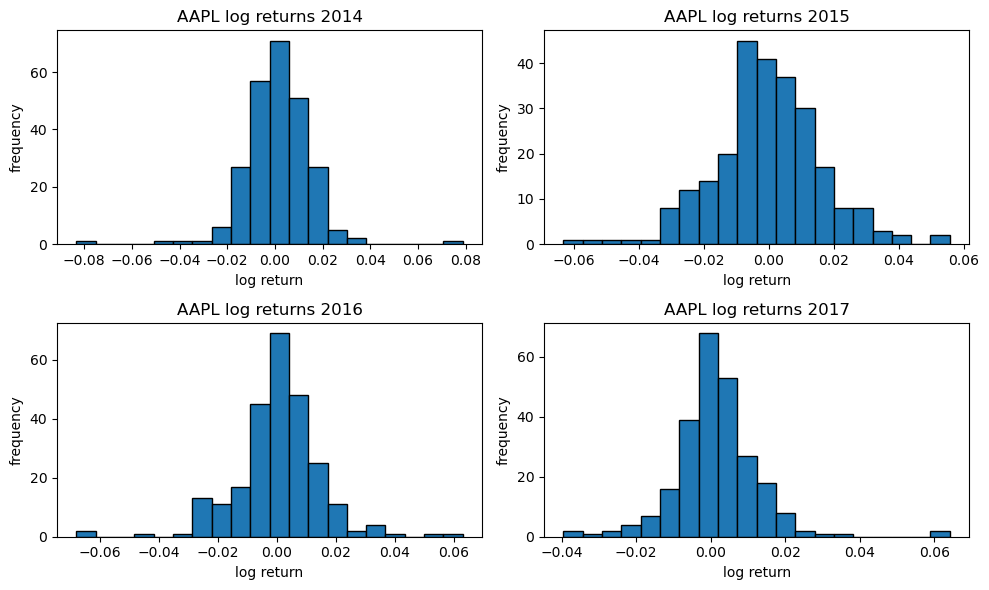

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load SP 500 stock prices
sp500 = pd.read_csv("SP 500 Stock Prices.csv", parse_dates=["date"])

# Select AAPL and compute daily log returns
aapl = sp500[sp500["symbol"] == "AAPL"].sort_values("date").copy()
aapl["log_return"] = np.log(aapl["close"]).diff()
# Drop first row per year with NaN log return
aapl = aapl.dropna(subset=["log_return"])  # drops the very first date overall

# Add year column
aapl["year"] = aapl["date"].dt.year

# --- Table: summary stats of log returns by year ---
summary = (
    aapl.groupby("year")["log_return"]
        .agg(n="count", mean="mean", std="std", min="min", max="max")
        .reset_index()
)

print("AAPL log returns by calendar year (from SP 500 Stock Prices.csv):")
print(summary.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# --- Empirical histograms of log returns by year (bins=20) ---
years = sorted(aapl["year"].unique())
nyears = len(years)
cols = 2
rows = int(np.ceil(nyears / cols))

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows), sharex=False)
axes = np.atleast_1d(axes).ravel()

for ax, yr in zip(axes, years):
    data = aapl.loc[aapl["year"] == yr, "log_return"]
    ax.hist(data, bins=20, edgecolor="black")
    ax.set_title(f"AAPL log returns {yr}")
    ax.set_xlabel("log return")
    ax.set_ylabel("frequency")

# Hide any unused subplots
for ax in axes[len(years):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [5]:
# --- Method comparison: Mean, MAD, %Error, Skewness, Kurtosis for True, Midpoint, Rectangles Octile, C-Trapezoid ---
import numpy as np
import pandas as pd

def empirical_octiles(x):
    O = [0.0]
    for i in range(1, 8):
        O.append(float(np.quantile(x, i / 8.0)))
    return np.array(O)

def compute_method_stats(returns, symbol_name="Stock"):
    """Returns DataFrame with Mean, MAD, %Err μ, %Err MAD, Skewness, Kurtosis for each method."""
    x = np.asarray(returns, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 8:
        return None
    O = empirical_octiles(x)
    Q1, M, Q3 = float(np.quantile(x, 0.25)), float(np.median(x)), float(np.quantile(x, 0.75))
    O1, O2, O3, O4, O5, O6, O7 = O[1], O[2], O[3], O[4], O[5], O[6], O[7]

    # True (from data)
    true_mu = float(np.mean(x))
    true_H = float(np.mean(np.abs(x - np.median(x))))
    true_skew = float(pd.Series(x).skew())
    true_kurt = float(pd.Series(x).kurtosis())

    def pct_err(est, true_val):
        if np.abs(true_val) < 1e-12:
            return np.nan
        return 100.0 * (est - true_val) / np.abs(true_val)

    rows = []

    # Midpoint: μ=(O2+O6)/2, H=(O6-O2)/2
    mid_mu = (O2 + O6) / 2.0
    mid_H = (O6 - O2) / 2.0 if (O6 - O2) > 1e-12 else np.nan
    mid_G = ((O7 - O5) - (O3 - O1)) / (O6 - O2) if (O6 - O2) > 1e-12 else np.nan
    mid_K = ((O3 - O1) + (O7 - O5)) / (O6 - O2) if (O6 - O2) > 1e-12 else np.nan
    rows.append({"Method": "True (from data)", "Mean": true_mu, "%Err μ": "--", "MAD": true_H, "%Err MAD": "--", "Skewness": true_skew, "Kurtosis": true_kurt, "%Err skew": "--", "%Err kurt": "--"})
    rows.append({"Method": "Midpoint", "Mean": mid_mu, "%Err μ": pct_err(mid_mu, true_mu), "MAD": mid_H, "%Err MAD": pct_err(mid_H, true_H), "Skewness": mid_G, "Kurtosis": mid_K, "%Err skew": pct_err(mid_G, true_skew), "%Err kurt": pct_err(mid_K, true_kurt)})

    # Rectangles Octile (all-octile): I1=(O1+O2+O3+O4)/8, I2=(O4+O5+O6+O7)/8
    I1_rect = (O1 + O2 + O3 + O4) / 8.0
    I2_rect = (O4 + O5 + O6 + O7) / 8.0
    rect_mu = I1_rect + I2_rect
    rect_H = I2_rect - I1_rect
    denom_rect = (O4 + O5 + O6 + O7) - (O1 + O2 + O3 + O4)
    rect_G = 2.0 * (((O6 + O7) - (O4 + O5)) - ((O3 + O4) - (O1 + O2))) / denom_rect if np.abs(denom_rect) > 1e-12 else np.nan
    rect_K = (((O3 + O4) - (O1 + O2)) + ((O6 + O7) - (O4 + O5))) / denom_rect if np.abs(denom_rect) > 1e-12 else np.nan
    rows.append({"Method": "Rectangles Octile", "Mean": rect_mu, "%Err μ": pct_err(rect_mu, true_mu), "MAD": rect_H, "%Err MAD": pct_err(rect_H, true_H), "Skewness": rect_G, "Kurtosis": rect_K, "%Err skew": pct_err(rect_G, true_skew), "%Err kurt": pct_err(rect_K, true_kurt)})

    # C-Trapezoid: C_L=4O1-6O2+4O3-O4, C_R=-O4+4O5-6O6+4O7, I1=(3O1-2O2+3O3)/8, I2=(3O5-2O6+3O7)/8
    C_L = 4.0 * O1 - 6.0 * O2 + 4.0 * O3 - O4
    C_R = -O4 + 4.0 * O5 - 6.0 * O6 + 4.0 * O7
    I1_ct = (3.0 * O1 - 2.0 * O2 + 3.0 * O3) / 8.0
    I2_ct = (3.0 * O5 - 2.0 * O6 + 3.0 * O7) / 8.0
    ct_mu = I1_ct + I2_ct
    ct_H = I2_ct - I1_ct
    denom_ct = (O4 + 2*O5 + 2*O6 + 2*O7 + C_R) - (C_L + 2*O1 + 2*O2 + 2*O3 + O4)
    num_G_ct = 6.0 * (O7 + O1) - 6.0 * (O6 + O2) + 2.0 * (O3 + O5 - 2*O4)
    denom_G_ct = 3.0 * (O7 + O5) - 3.0 * (O3 + O1) - 2.0 * (O6 - O2)
    ct_G = num_G_ct / denom_G_ct if np.abs(denom_G_ct) > 1e-12 else np.nan
    num_K_ct = ((O2 + 2*O3 + O4) - (C_L + 2*O1 + O2)) + ((O6 + 2*O7 + C_R) - (O4 + 2*O5 + O6))
    ct_K = num_K_ct / denom_ct if np.abs(denom_ct) > 1e-12 else np.nan
    rows.append({"Method": "C-Trapezoid", "Mean": ct_mu, "%Err μ": pct_err(ct_mu, true_mu), "MAD": ct_H, "%Err MAD": pct_err(ct_H, true_H), "Skewness": ct_G, "Kurtosis": ct_K, "%Err skew": pct_err(ct_G, true_skew), "%Err kurt": pct_err(ct_K, true_kurt)})

    return pd.DataFrame(rows)

# Load SP500 and compute for each stock
sp500 = pd.read_csv("SP 500 Stock Prices.csv", parse_dates=["date"])
symbols = sorted(sp500["symbol"].unique())

# Compute table for AAPL (main example for paper) — per year
aapl_data = sp500[sp500["symbol"] == "AAPL"].sort_values("date").copy()
aapl_data["year"] = aapl_data["date"].dt.year
aapl_data["return"] = aapl_data["close"].pct_change() * 100  # % return
aapl_data = aapl_data.dropna(subset=["return"])

years = sorted(aapl_data["year"].unique())
for yr in years:
    ret_yr = aapl_data.loc[aapl_data["year"] == yr, "return"].values
    df_yr = compute_method_stats(ret_yr)
    if df_yr is not None:
        print(f"\n{'='*80}")
        print(f"AAPL simple returns (%) — Year {yr} (n={len(ret_yr)})")
        print("="*80)
        print(df_yr.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else str(x)))

# Also compute for full series (all years combined)
df_aapl = compute_method_stats(aapl_data["return"].values, "AAPL")
print(f"\n{'='*80}")
print("AAPL simple returns (%) — All years combined")
print("="*80)
print(df_aapl.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else str(x)))

# Option: compute for all stocks and all years
all_results = []
for sym in symbols:
    sub = sp500[sp500["symbol"] == sym].sort_values("date").copy()
    sub["year"] = sub["date"].dt.year
    sub["return"] = sub["close"].pct_change() * 100  # % return
    sub = sub.dropna(subset=["return"])
    for yr in sub["year"].unique():
        ret = sub.loc[sub["year"] == yr, "return"].values
        df = compute_method_stats(ret, sym)
        if df is not None:
            df["symbol"] = sym
            df["year"] = yr
            all_results.append(df)
if all_results:
    combined = pd.concat(all_results, ignore_index=True)
    print("\n--- LaTeX table row template for main.tex (AAPL, all years) ---")
    r = df_aapl
    def fmt1(v):
        if v == "--" or isinstance(v, str):
            return str(v)
        return f"{v:.1f}"
    for _, row in r.iterrows():
        h = row["MAD"]
        eH = row["%Err MAD"]
        sk = row["Skewness"]
        eSk = row["%Err skew"]
        ku = row["Kurtosis"]
        eKu = row["%Err kurt"]
        eHs = "--" if isinstance(eH, str) or pd.isna(eH) else f"{eH:.1f}"
        eSks = "--" if isinstance(eSk, str) or pd.isna(eSk) else f"{eSk:.1f}"
        eKus = "--" if isinstance(eKu, str) or pd.isna(eKu) else f"{eKu:.1f}"
        print(f"{row['Method']} & {fmt1(h)} & {eHs} & {fmt1(sk)} & {eSks} & {fmt1(ku)} & {eKus} \\\\")


AAPL simple returns (%) — Year 2014 (n=251)
           Method   Mean   %Err μ    MAD %Err MAD  Skewness  Kurtosis %Err skew %Err kurt
 True (from data) 0.1425       -- 0.9475       --   -0.1307    9.2577        --        --
         Midpoint 0.1888  32.4590 0.7748 -18.2242    0.0530    1.2187  140.5518  -86.8358
Rectangles Octile 0.1386  -2.7714 0.5878 -37.9620    0.1113    0.7312  185.1593  -92.1023
      C-Trapezoid 0.1055 -26.0041 0.7949 -16.1058   -0.0575    0.5575   55.9958  -93.9779

AAPL simple returns (%) — Year 2015 (n=252)
           Method    Mean     %Err μ    MAD %Err MAD  Skewness  Kurtosis %Err skew %Err kurt
 True (from data) -0.0047         -- 1.2621       --    0.0183    1.3485        --        --
         Midpoint  0.0327   793.5262 0.9098 -27.9126   -0.0802    1.4789 -537.7679    9.6685
Rectangles Octile -0.0280  -494.7023 0.7996 -36.6474    0.0281    0.7052   53.1979  -47.7076
      C-Trapezoid -0.0612 -1197.1487 1.2615  -0.0515   -0.0814    0.6328 -544.5891  -53.

AAPL simple returns by calendar year (from SP 500 Stock Prices.csv)
Returns in %. n=count, skew=skewness, kurtosis=excess kurtosis.
 year   n    mean    std     min    max    skew  kurtosis
 2014 251  0.1425 1.3649 -7.9927 8.1982 -0.1307    9.2577
 2015 252 -0.0047 1.6841 -6.1163 5.7355  0.0183    1.3485
 2016 252  0.0488 1.4722 -6.5707 6.4963 -0.1726    4.2750
 2017 251  0.1577 1.1517 -3.8777 6.6295  0.9510    7.0776


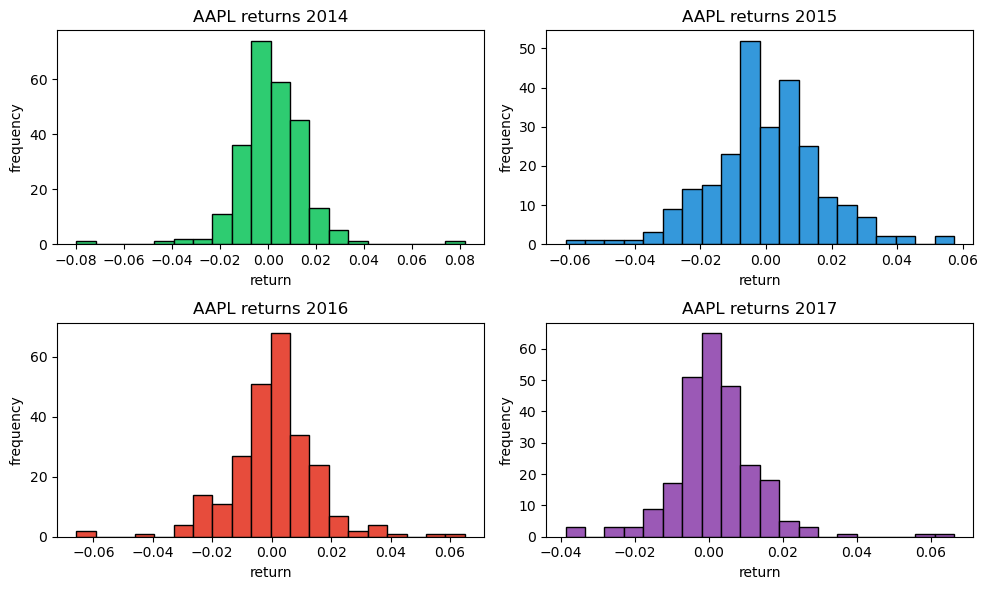

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load SP 500 stock prices
sp500 = pd.read_csv("SP 500 Stock Prices.csv", parse_dates=["date"])

# Select AAPL and compute daily simple returns
aapl = sp500[sp500["symbol"] == "AAPL"].sort_values("date").copy()
# Simple return r_t = (P_t / P_{t-1}) - 1
aapl["return"] = aapl["close"].pct_change()
aapl = aapl.dropna(subset=["return"])  # drops the first row (no previous price)

# Add year column
aapl["year"] = aapl["date"].dt.year

# --- Table: summary stats of returns by year (one multi-row table, returns in %) ---
summary = (
    aapl.groupby("year")["return"]
        .agg(
            n="count",
            mean="mean",
            std="std",
            min="min",
            max="max",
            skew="skew",
            kurtosis=lambda x: x.kurtosis(),
        )
        .reset_index()
)
# Convert return columns to %
for col in ["mean", "std", "min", "max"]:
    summary[col] = summary[col] * 100
summary["n"] = summary["n"].astype(int)

print("AAPL simple returns by calendar year (from SP 500 Stock Prices.csv)")
print("Returns in %. n=count, skew=skewness, kurtosis=excess kurtosis.")
print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))

# --- Empirical histograms of returns by year (bins=20) ---
years = sorted(aapl["year"].unique())
nyears = len(years)
cols = 2
rows = int(np.ceil(nyears / cols))

fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows), sharex=False)
axes = np.atleast_1d(axes).ravel()

# 4 distinct colors for years (cycles if more than 4)
colors = ["#2ecc71", "#3498db", "#e74c3c", "#9b59b6"]
for ax, yr in zip(axes, years):
    data = aapl.loc[aapl["year"] == yr, "return"]
    color = colors[(yr - years[0]) % len(colors)]
    ax.hist(data, bins=20, edgecolor="black", color=color)
    ax.set_title(f"AAPL returns {yr}")
    ax.set_xlabel("return")
    ax.set_ylabel("frequency")

# Hide any unused subplots
for ax in axes[len(years):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
# Compute mean and MAD using Strategy 1 (Average of Quadratics) for all distributions
# Run the first cell before this one (octile helpers, quadratic_avg_trapezoid_mean_mad).

import math
import numpy as np
from statistics import NormalDist

# Local helpers for true MAD so this cell can build the list without depending on first cell for these
_std_normal = NormalDist()
def _compute_true_h(q_func, eps=1e-6, num=5000):
    ps_lower = np.linspace(eps, 0.5, num)
    ps_upper = np.linspace(0.5, 1 - eps, num)
    I1 = np.trapezoid(np.array([q_func(p) for p in ps_lower]), ps_lower)
    I2 = np.trapezoid(np.array([q_func(p) for p in ps_upper]), ps_upper)
    return I2 - I1
def _pareto_last_area(alpha=2.0, beta=0.5):
    return beta * alpha / (alpha - 1) * ((1/8) ** ((alpha - 1) / alpha))

print("=" * 120)
print("AVERAGE OF QUADRATICS (STRATEGY 1) FOR Q(0) AND Q(1) WITH TRAPEZOID INTEGRATION")
print("=" * 120)

# Define all distributions (Laplace MAD = λ = 1; octile_func and quadratic_avg_trapezoid_mean_mad from first cell)
distributions = [
    ("Laplace", lambda: compute_octiles_laplace(0, 1), 0, 1.0, None),
    ("Exponential", lambda: compute_octiles_exponential(1), 1, math.log(2), 
     lambda: (1/8) * (1 - math.log(1/8))),
    ("Uniform", lambda: compute_octiles_uniform(), 0.5, 0.25, None),
    ("Pareto", lambda: compute_octiles_pareto(2.0, 1/2), 
     2.0 * (1/2) / (2.0 - 1), 
     (1/2) * 2.0 * ((2**(1/2.0))-1)/(2.0 - 1), 
     lambda: _pareto_last_area(2.0, 0.5)),
    ("Power", lambda: compute_octiles_power(2.0), 
     2.0 / (2.0 + 1), 
     _compute_true_h(lambda p, a=2.0: p**(1/a)), None),
    ("Log-normal", lambda: compute_octiles_lognormal(0, 1), 
     math.exp(0 + (1**2)/2), 
     _compute_true_h(lambda p, m=0, s=1: math.exp(m + s * _std_normal.inv_cdf(p))), None),
    ("Normal", lambda: compute_octiles_normal(0, 1), 
     0, 
     _compute_true_h(lambda p, nd=NormalDist(0, 1): nd.inv_cdf(p)), None),
    ("Weibull", lambda: compute_octiles_weibull(2.0, 1.0), 
     1.0 * math.gamma(1 + 1/2.0), 
     _compute_true_h(lambda p, s=2.0, b=1.0: b * ((-math.log(1-p))**(1/s)), eps=1e-6), None),
]

results = []

for dist_name, octile_func, true_mu, true_h, last_area_func in distributions:
    octiles = octile_func()
    O = np.array(octiles)
    
    # Q(0) approximations
    p_q1 = np.array([1/8, 2/8, 3/8])
    o_q1 = np.array([O[1], O[2], O[3]])
    a1, b1, c1 = np.polyfit(p_q1, o_q1, 2)
    Q_0_1 = c1
    
    p_q2 = np.array([2/8, 3/8, 4/8])
    o_q2 = np.array([O[2], O[3], O[4]])
    a2, b2, c2 = np.polyfit(p_q2, o_q2, 2)
    Q_0_2 = c2
    
    Q_0_avg = (Q_0_1 + Q_0_2) / 2
    
    # Q(1) approximations
    p_q3 = np.array([5/8, 6/8, 7/8])
    o_q3 = np.array([O[5], O[6], O[7]])
    a3, b3, c3 = np.polyfit(p_q3, o_q3, 2)
    Q_1_1 = a3 + b3 + c3
    
    p_q4 = np.array([4/8, 5/8, 6/8])
    o_q4 = np.array([O[4], O[5], O[6]])
    a4, b4, c4 = np.polyfit(p_q4, o_q4, 2)
    Q_1_2 = a4 + b4 + c4
    
    Q_1_avg = (Q_1_1 + Q_1_2) / 2
    
    # Print quadratic approximations for this distribution
    print(f"\n{dist_name} Distribution:")
    print("-" * 120)
    print(f"Q(0) approximations:")
    print(f"  Quadratic 1 (from points 1/8, 2/8, 3/8): Q(0) = {Q_0_1:.6f}")
    print(f"  Quadratic 2 (from points 2/8, 3/8, 4/8): Q(0) = {Q_0_2:.6f}")
    print(f"  Average: Q(0) ≈ {Q_0_avg:.6f}")
    print(f"\nQ(1) approximations:")
    print(f"  Quadratic 1 (from points 5/8, 6/8, 7/8): Q(1) = {Q_1_1:.6f}")
    print(f"  Quadratic 2 (from points 4/8, 5/8, 6/8): Q(1) = {Q_1_2:.6f}")
    print(f"  Average: Q(1) ≈ {Q_1_avg:.6f}")
    
    # Compute mean and MAD using these approximations
    mean_quad_avg, mad_quad_avg = quadratic_avg_trapezoid_mean_mad(octiles, last_area_func)
    
    mean_err = abs((mean_quad_avg - true_mu) / true_mu) * 100 if abs(true_mu) > 1e-10 else abs(mean_quad_avg - true_mu)
    mad_err = abs((mad_quad_avg - true_h) / true_h) * 100 if abs(true_h) > 1e-10 else abs(mad_quad_avg - true_h)
    
    print(f"\nResults: Mean = {mean_quad_avg:.6f} (Err: {mean_err:.4f}%), MAD = {mad_quad_avg:.6f} (Err: {mad_err:.4f}%)")
    print("-" * 120)
    
    results.append((dist_name, mean_quad_avg, mean_err, mad_quad_avg, mad_err))

# Summary table
print("\n" + "=" * 120)
print("SUMMARY TABLE")
print("=" * 120)
print(f"{'Distribution':<15} {'Mean':<15} {'Mean Err %':<15} {'MAD':<15} {'MAD Err %':<15}")
print("-" * 120)

for dist_name, mean_val, mean_err, mad_val, mad_err in results:
    print(f"{dist_name:<15} {mean_val:<15.6f} {mean_err:<15.4f} {mad_val:<15.6f} {mad_err:<15.4f}")

print("=" * 120)

AVERAGE OF QUADRATICS (STRATEGY 1) FOR Q(0) AND Q(1) WITH TRAPEZOID INTEGRATION

Laplace Distribution:
------------------------------------------------------------------------------------------------------------------------
Q(0) approximations:
  Quadratic 1 (from points 1/8, 2/8, 3/8): Q(0) = -2.367124
  Quadratic 2 (from points 2/8, 3/8, 4/8): Q(0) = -1.857427
  Average: Q(0) ≈ -2.112275

Q(1) approximations:
  Quadratic 1 (from points 5/8, 6/8, 7/8): Q(1) = 2.367124
  Quadratic 2 (from points 4/8, 5/8, 6/8): Q(1) = 1.857427
  Average: Q(1) ≈ 2.112275

Results: Mean = -0.000000 (Err: 0.0000%), MAD = 0.855815 (Err: 14.4185%)
------------------------------------------------------------------------------------------------------------------------

Exponential Distribution:
------------------------------------------------------------------------------------------------------------------------
Q(0) approximations:
  Quadratic 1 (from points 1/8, 2/8, 3/8): Q(0) = 0.007552
  Quadratic 2 (fr

In [8]:
## Estimate λ: MLE, Mean-fit, + MAD (1-rect, 2-quart, 4-oct, all-oct, cubic+trap)
## Distributions: Exponential, Laplace, Uniform, Pareto, Normal, Weibull, Power, Log-normal.
## Report Mean(λ̂) per (n, method). Formulas from main.tex.

import math
import numpy as np
from scipy import stats
from scipy.special import gamma, gammaincc
from scipy.optimize import minimize_scalar

np.random.seed(42)
N_REPS = 500
SAMPLE_SIZES = [50, 100, 200]

QUAD_METHODS = ["1-rectangle", "2-quartile", "4-octile", "all-octile", "cubic+trapezoid"]
EXTRA_METHODS = ["MLE", "Mean-fit"]
ALL_METHODS = EXTRA_METHODS + QUAD_METHODS

def empirical_octiles(x):
    O = [0.0]
    for i in range(1, 8):
        O.append(float(np.quantile(x, i / 8.0)))
    return np.array(O)

def empirical_quartiles(x):
    q = np.quantile(x, [0.25, 0.5, 0.75])
    return float(q[0]), float(q[1]), float(q[2])

def quad_mu_H_I1_I2(method, x, O, Q1, M, Q3):
    """Return (mu, H, I1, I2) for the given quadrature method."""
    if method == "1-rectangle":
        mu = M
        H = (Q3 - Q1) / 2.0 if (Q3 - Q1) > 1e-12 else np.nan
        I1 = (mu - H) / 2.0
        I2 = (mu + H) / 2.0
    elif method == "2-quartile":
        mu = (Q1 + Q3) / 2.0
        H = (Q3 - Q1) / 2.0 if (Q3 - Q1) > 1e-12 else np.nan
        I1 = (mu - H) / 2.0
        I2 = (mu + H) / 2.0
    elif method == "4-octile":
        I1 = (O[1] + O[3]) / 4.0
        I2 = (O[5] + O[7]) / 4.0
        mu = I1 + I2
        H = I2 - I1
    elif method == "all-octile":
        I1 = (O[1] + O[2] + O[3] + O[4]) / 8.0
        I2 = (O[4] + O[5] + O[6] + O[7]) / 8.0
        mu = I1 + I2
        H = I2 - I1
    elif method == "cubic+trapezoid":
        I1 = (3.0 * O[1] - 2.0 * O[2] + 3.0 * O[3]) / 8.0
        I2 = (3.0 * O[5] - 2.0 * O[6] + 3.0 * O[7]) / 8.0
        mu = I1 + I2
        H = I2 - I1
    elif method == "weighted-octile":
        # Rectangle + trapezoids (main.tex): I1=(3O1+2O2+2O3+O4)/16, I2=(O4+2O5+2O6+3O7)/16
        I1 = (3.0 * O[1] + 2.0 * O[2] + 2.0 * O[3] + O[4]) / 16.0
        I2 = (O[4] + 2.0 * O[5] + 2.0 * O[6] + 3.0 * O[7]) / 16.0
        mu = I1 + I2
        H = I2 - I1
    else:
        raise ValueError(method)
    return mu, H, I1, I2

def weibull_H(lam, k):
    lg2 = math.log(2)
    u = (lam ** k) * lg2
    g1 = gamma(1.0 / k)
    g1_up = g1 * gammaincc(1.0 / k, u)
    return lam * ((lg2 ** (1.0 / k)) + (2.0 / k) * g1_up - (1.0 / k) * g1)

def lambda_from_quad(dist_key, method, x, O, Q1, M, Q3, **kwargs):
    mu, H, I1, I2 = quad_mu_H_I1_I2(method, x, O, Q1, M, Q3)
    if not (np.isfinite(mu) and np.isfinite(H) and H > 1e-12):
        return np.nan
    s = I1 + I2
    if dist_key == "Exponential":
        return math.log(2) / H
    if dist_key == "Laplace":
        return H
    if dist_key == "Uniform":
        return 4.0 * H
    if dist_key == "Pareto":
        if s <= 1e-12 or I2 <= 1e-12:
            return np.nan
        t = (math.log(s) - math.log(I2)) / math.log(2)
        return float(s * (1.0 - t)) if 0 < t < 1 else np.nan
    if dist_key == "Normal":
        return np.sqrt(np.pi / 2.0) * H
    if dist_key == "Weibull":
        k = kwargs.get("k", 2.0)
        def obj(lam):
            return (weibull_H(lam, k) - H) ** 2
        try:
            r = minimize_scalar(obj, bounds=(1e-6, 5.0), method="bounded")
            return float(r.x) if r.success else np.nan
        except Exception:
            return np.nan
    if dist_key == "Power":
        beta = kwargs.get("beta", 2.0)
        return (beta + 1.0) * H / (1.0 - 0.5 ** beta)
    if dist_key == "Log-normal":
        if s <= 1e-12 or I2 <= 1e-12:
            return np.nan
        r = I2 / s
        if not (1e-6 < r < 1 - 1e-6):
            return np.nan
        return float(stats.norm.ppf(r))
    return np.nan

def lambda_mle(dist_key, x, **kwargs):
    """MLE of λ for each distribution."""
    if dist_key == "Exponential":
        return 1.0 / np.mean(x) if np.mean(x) > 1e-12 else np.nan
    if dist_key == "Laplace":
        return float(np.mean(np.abs(x - np.median(x))))
    if dist_key == "Uniform":
        return float(np.max(x) - np.min(x))
    if dist_key == "Pareto":
        _, _, scale = stats.pareto.fit(x, floc=0, f0=2.0)
        return float(scale)
    if dist_key == "Normal":
        return float(np.std(x, ddof=0)) if np.size(x) > 1 else np.nan
    if dist_key == "Weibull":
        _, _, scale = stats.weibull_min.fit(x, floc=0, f0=2.0)
        return float(scale)
    if dist_key == "Power":
        return float(np.mean(x) * 3.0)
    if dist_key == "Log-normal":
        s, _, _ = stats.lognorm.fit(x, floc=0)
        return float(s)
    return np.nan

def lambda_meanfit(dist_key, x, **kwargs):
    """Fit mean exactly: E[X] = sample mean, solve for λ."""
    mu = np.mean(x)
    if dist_key == "Exponential":
        return 1.0 / mu if mu > 1e-12 else np.nan
    if dist_key == "Laplace":
        return float(np.mean(np.abs(x - mu)))
    if dist_key == "Uniform":
        return float(np.sqrt(12.0) * np.std(x, ddof=0)) if np.size(x) > 1 else np.nan
    if dist_key == "Pareto":
        return float(mu * 0.5) if mu > 1e-12 else np.nan  # α=2: β = μ(α-1)/α = μ/2
    if dist_key == "Normal":
        return float(np.std(x, ddof=0)) if np.size(x) > 1 else np.nan
    if dist_key == "Weibull":
        return float(mu) / math.gamma(1.5)
    if dist_key == "Power":
        return float(mu * 3.0)  # μ = C/3
    if dist_key == "Log-normal":
        s, _, _ = stats.lognorm.fit(x, floc=0)
        return float(s)
    return np.nan

def _rv_power(C, beta, size, rng):
    u = rng.uniform(0, 1, size=size)
    return C * (u ** beta)

def run_one(dist_key, n, rng):
    res = {"true": None, "x": None, "O": None, "Q1": None, "M": None, "Q3": None}
    if dist_key == "Exponential":
        lam = 1.0
        x = stats.expon(scale=1.0 / lam).rvs(size=n, random_state=rng)
        res["true"] = lam
    elif dist_key == "Laplace":
        x = stats.laplace(loc=0, scale=1).rvs(size=n, random_state=rng)
        res["true"] = 1.0
    elif dist_key == "Uniform":
        x = stats.uniform(loc=0, scale=1).rvs(size=n, random_state=rng)
        res["true"] = 1.0
    elif dist_key == "Pareto":
        x = stats.pareto(b=2, scale=0.5).rvs(size=n, random_state=rng)
        res["true"] = 0.5
    elif dist_key == "Normal":
        x = stats.norm(loc=0, scale=1).rvs(size=n, random_state=rng)
        res["true"] = 1.0
    elif dist_key == "Weibull":
        x = stats.weibull_min(c=2, scale=1).rvs(size=n, random_state=rng)
        res["true"] = 1.0
    elif dist_key == "Power":
        x = _rv_power(1.0, 2.0, n, rng)
        res["true"] = 1.0
    elif dist_key == "Log-normal":
        x = stats.lognorm(s=1, scale=1).rvs(size=n, random_state=rng)
        res["true"] = 1.0
    else:
        raise ValueError(dist_key)
    res["x"] = x
    res["O"] = empirical_octiles(x)
    res["Q1"], res["M"], res["Q3"] = empirical_quartiles(x)
    kwargs = {}
    if dist_key == "Weibull":
        kwargs["k"] = 2.0
    if dist_key == "Power":
        kwargs["beta"] = 2.0
    res["MLE"] = lambda_mle(dist_key, x, **kwargs)
    res["Mean-fit"] = lambda_meanfit(dist_key, x, **kwargs)
    for m in QUAD_METHODS:
        res[m] = lambda_from_quad(dist_key, m, res["x"], res["O"], res["Q1"], res["M"], res["Q3"], **kwargs)
    return res

DISTRIBUTIONS = ["Exponential", "Laplace", "Uniform", "Pareto", "Normal", "Weibull", "Power", "Log-normal"]
PARAM_NAMES = {
    "Exponential": "λ (rate)", "Laplace": "λ (scale)", "Uniform": "λ (b-a)",
    "Pareto": "λ (β)", "Normal": "λ (σ)", "Weibull": "λ (scale)",
    "Power": "λ (C)", "Log-normal": "λ (σ)",
}

results = {d: {n: {m: [] for m in ALL_METHODS} for n in SAMPLE_SIZES} for d in DISTRIBUTIONS}
rng = np.random.default_rng(42)

for dist in DISTRIBUTIONS:
    for n in SAMPLE_SIZES:
        for _ in range(N_REPS):
            r = run_one(dist, n, rng)
            for m in ALL_METHODS:
                v = r[m]
                if np.isfinite(v):
                    results[dist][n][m].append(v)

print("Estimate λ: MLE, Mean-fit, + MAD (1-rect, 2-quart, 4-oct, all-oct, cubic+trap). n = 50, 100, 200.")
print("Mean(λ̂) over replicates.")
print()

for dist in DISTRIBUTIONS:
    true_val = run_one(dist, 100, np.random.default_rng(0))["true"]
    print("=" * 140)
    print(f"{dist} (true {PARAM_NAMES[dist]} = {true_val})")
    print("=" * 140)
    print(f"{'n':<6} " + " ".join(f"{m:<18}" for m in ALL_METHODS))
    print("-" * 140)
    for n in SAMPLE_SIZES:
        row = [f"{n:<6}"]
        for m in ALL_METHODS:
            arr = np.array(results[dist][n][m])
            mean_est = float(np.mean(arr)) if len(arr) > 0 else np.nan
            row.append(f"{mean_est:<18.4f}" if np.isfinite(mean_est) else f"{'nan':<18}")
        print(" ".join(row))
    print()

print("Done.")

Estimate λ: MLE, Mean-fit, + MAD (1-rect, 2-quart, 4-oct, all-oct, cubic+trap). n = 50, 100, 200.
Mean(λ̂) over replicates.

Exponential (true λ (rate) = 1.0)
n      MLE                Mean-fit           1-rectangle        2-quartile         4-octile           all-octile         cubic+trapezoid   
--------------------------------------------------------------------------------------------------------------------------------------------
50     1.0196             1.0196             1.3657             1.3657             1.1939             1.6541             1.1372            
100    1.0073             1.0073             1.3106             1.3106             1.1704             1.6146             1.1181            
200    1.0061             1.0061             1.2815             1.2815             1.1487             1.5847             1.0955            

Laplace (true λ (scale) = 1.0)
n      MLE                Mean-fit           1-rectangle        2-quartile         4-octile           all-oc

## All distributions: C-trapezoid vs median vs octile-average

In [9]:
# Parameter estimation: C-trapezoid vs median vs octile-average
# All distributions: 100 Monte Carlo reps, N=100 or 200. Question: Is (b) better than (d)?

import math
import numpy as np
from scipy import stats
from scipy.special import gamma, gammaincc
from scipy.optimize import minimize_scalar

N_REPS = 100
SAMPLE_SIZES = [100, 200]
rng = np.random.default_rng(42)

def octiles(x):
    return [0.0] + [float(np.quantile(x, i / 8.0)) for i in range(1, 8)]

def weibull_H(lam, k):
    lg2 = math.log(2)
    u = (lam ** k) * lg2
    g1 = gamma(1.0 / k)
    g1_up = g1 * gammaincc(1.0 / k, u)
    return lam * ((lg2 ** (1.0 / k)) + (2.0 / k) * g1_up - (1.0 / k) * g1)

def sample_gen(dist_key, n, rng):
    if dist_key == "Exponential":
        return stats.expon(scale=1.0).rvs(size=n, random_state=rng), 1.0
    if dist_key == "Laplace":
        return stats.laplace(0, 1).rvs(size=n, random_state=rng), 1.0
    if dist_key == "Uniform":
        return stats.uniform(0, 1).rvs(size=n, random_state=rng), 1.0
    if dist_key == "Pareto":
        return stats.pareto(b=2, scale=0.5).rvs(size=n, random_state=rng), 0.5
    if dist_key == "Normal":
        return stats.norm(0, 1).rvs(size=n, random_state=rng), 1.0
    if dist_key == "Weibull":
        return stats.weibull_min(c=2, scale=1).rvs(size=n, random_state=rng), 1.0
    if dist_key == "Power":
        return (rng.uniform(0, 1, n) ** 2), 1.0  # X = C*U^beta, C=1, beta=2
    if dist_key == "Log-normal":
        return stats.lognorm(s=1, scale=1).rvs(size=n, random_state=rng), 1.0
    raise ValueError(dist_key)

def lambda_ctrap(dist_key, x):
    O = octiles(x)
    I1 = (3.0 * O[1] - 2.0 * O[2] + 3.0 * O[3]) / 8.0
    I2 = (3.0 * O[5] - 2.0 * O[6] + 3.0 * O[7]) / 8.0
    s, H = I1 + I2, I2 - I1
    O4 = O[4]
    if dist_key == "Exponential":
        return 1.0 / s if s > 1e-12 else np.nan
    if dist_key == "Laplace":
        return float(H) if np.isfinite(H) else np.nan
    if dist_key == "Uniform":
        return float(4 * H) if np.isfinite(H) and H > 1e-12 else np.nan
    if dist_key == "Pareto":
        return float(s * O4 / (2 * I2)) if I2 > 1e-12 else np.nan
    if dist_key == "Normal":
        return float(H * math.sqrt(math.pi / 2)) if np.isfinite(H) else np.nan
    if dist_key == "Weibull":
        def obj(lam): return (weibull_H(lam, 2) - H) ** 2
        try:
            r = minimize_scalar(obj, bounds=(1e-6, 5), method="bounded")
            return float(r.x) if r.success else np.nan
        except: return np.nan
    if dist_key == "Power":
        return float(s * O4 / (2 * I1)) if I1 > 1e-12 else np.nan
    if dist_key == "Log-normal":
        r = I2 / s if s > 1e-12 else np.nan
        return float(stats.norm.ppf(r)) if 1e-6 < r < 1-1e-6 else np.nan
    return np.nan

def lambda_mad(dist_key, x):
    """Parameter from sample MAD = mean(|X - median(X)|). H = MAD."""
    m = np.median(x)
    H = float(np.mean(np.abs(x - m)))
    if H < 1e-12:
        return np.nan
    if dist_key == "Exponential":
        return math.log(2) / H
    if dist_key == "Laplace":
        return H
    if dist_key == "Uniform":
        return 4.0 * H
    if dist_key == "Normal":
        return H * math.sqrt(math.pi / 2)
    if dist_key == "Weibull":
        def obj(lam): return (weibull_H(lam, 2) - H) ** 2
        try:
            r = minimize_scalar(obj, bounds=(1e-6, 5), method="bounded")
            return float(r.x) if r.success else np.nan
        except: return np.nan
    if dist_key == "Pareto":
        s = 2.0 * np.mean(x)
        I2 = (s + H) / 2.0
        return float(s * m / (2 * I2)) if I2 > 1e-12 else np.nan
    if dist_key == "Power":
        return 4.0 * H  # Power(β=2): H = C/4, so C = 4*H
    if dist_key == "Log-normal":
        s = float(np.mean(x)) if np.mean(x) > 1e-12 else 1.0
        I2 = (s + H) / 2.0
        r = I2 / s if s > 1e-12 else np.nan
        return float(stats.norm.ppf(r)) if 1e-6 < r < 1 - 1e-6 else np.nan
    return np.nan

def lambda_median(dist_key, x):
    m = np.median(x)
    if dist_key == "Exponential":
        return math.log(2) / m if m > 1e-12 else np.nan
    if dist_key == "Laplace":
        return float(np.mean(np.abs(x - m)))
    if dist_key == "Uniform":
        return float(np.max(x) - np.min(x))
    if dist_key == "Pareto":
        return float(m / (2 ** 0.5)) if m > 1e-12 else np.nan
    if dist_key == "Normal":
        q = np.quantile(x, [0.25, 0.75])
        return float((q[1] - q[0]) / 1.349) if q[1] > q[0] else np.nan
    if dist_key == "Weibull":
        return float(m / (math.log(2) ** 0.5)) if m > 1e-12 else np.nan
    if dist_key == "Power":
        return float(m / 0.25) if m > 1e-12 else np.nan
    if dist_key == "Log-normal":
        q75 = np.quantile(x, 0.75)
        z = stats.norm.ppf(0.75)
        return float((math.log(q75) - math.log(m)) / z) if m > 0 and q75 > 0 else np.nan
    return np.nan

def lambda_octile_avg(dist_key, x):
    O = octiles(x)
    ests = []
    if dist_key == "Exponential":
        for i in range(1, 8):
            if O[i] > 1e-12:
                ests.append(math.log(8.0 / (8 - i)) / O[i])
    elif dist_key == "Laplace":
        for i in range(1, 5):
            denom = math.log(i / 4)
            if abs(denom) > 1e-12 and O[i] != 0:
                ests.append(O[i] / denom)
        for i in range(5, 8):
            denom = math.log(8.0 / (8 - i))
            if O[i] > 1e-12:
                ests.append(O[i] / denom)
    elif dist_key == "Uniform":
        for i in range(1, 8):
            d = O[i] - O[i-1]
            if d > 1e-12:
                ests.append(8 * d)
    elif dist_key == "Pareto":
        for i in range(1, 8):
            if O[i] > 1e-12:
                ests.append(O[i] * ((8 - i) / 8) ** 0.5)
    elif dist_key == "Normal":
        for i in [1, 2, 3, 5, 6, 7]:
            z = stats.norm.ppf(i / 8)
            if abs(z) > 1e-6 and np.isfinite(O[i]):
                ests.append(O[i] / z)
    elif dist_key == "Weibull":
        for i in range(1, 8):
            denom = math.log(8.0 / (8 - i)) ** 0.5
            if O[i] > 1e-12 and denom > 1e-12:
                ests.append(O[i] / denom)
    elif dist_key == "Power":
        for i in range(1, 8):
            if O[i] > 1e-12:
                ests.append(O[i] * 64 / (i * i))
    elif dist_key == "Log-normal":
        for i in [1, 2, 3, 5, 6, 7]:
            z = stats.norm.ppf(i / 8)
            if abs(z) > 1e-6 and O[i] > 1e-12:
                ests.append(math.log(O[i]) / z)
    return float(np.mean(ests)) if ests else np.nan

DISTRIBUTIONS = ["Exponential", "Laplace", "Uniform", "Pareto", "Normal", "Weibull", "Power", "Log-normal"]

def rel_err(est, true_val):
    return np.abs(est - true_val) / abs(true_val) * 100 if abs(true_val) > 1e-12 else 0

def run_study(dist_key, n):
    lam_ct, lam_med, lam_avg, lam_mad = [], [], [], []
    for rep in range(N_REPS):
        x, true_val = sample_gen(dist_key, n, rng)
        lam_ct.append(lambda_ctrap(dist_key, x))
        lam_med.append(lambda_median(dist_key, x))
        lam_avg.append(lambda_octile_avg(dist_key, x))
        lam_mad.append(lambda_mad(dist_key, x))
    return np.array(lam_ct), np.array(lam_med), np.array(lam_avg), np.array(lam_mad)

print("Parameter estimation: (b) C-trapezoid, (c) median, (d) octile-average, (e) MAD")
print("100 reps, N=100 or 200. Question: Is (b) better than (d)?")
print("=" * 80)
for dist in DISTRIBUTIONS:
    _, true_val = sample_gen(dist, 100, np.random.default_rng(0))
    print(f"\n{dist} (true param = {true_val})")
    print("-" * 60)
    for n in SAMPLE_SIZES:
        lam_ct, lam_med, lam_avg, lam_mad = run_study(dist, n)
        ct_ok = np.isfinite(lam_ct)
        med_ok = np.isfinite(lam_med)
        avg_ok = np.isfinite(lam_avg)
        mad_ok = np.isfinite(lam_mad)
        err_ct = np.mean(rel_err(lam_ct[ct_ok], true_val)) if np.any(ct_ok) else np.nan
        err_med = np.mean(rel_err(lam_med[med_ok], true_val)) if np.any(med_ok) else np.nan
        err_avg = np.mean(rel_err(lam_avg[avg_ok], true_val)) if np.any(avg_ok) else np.nan
        err_mad = np.mean(rel_err(lam_mad[mad_ok], true_val)) if np.any(mad_ok) else np.nan
        better = "C-trap (b)" if err_ct < err_avg else "oct-avg (d)"
        print(f"  N={n}:")
        print(f"    (b) C-trap:    mean λ̂={np.nanmean(lam_ct):.4f},  rel err%={err_ct:.1f}")
        print(f"    (c) median:    mean λ̂={np.nanmean(lam_med):.4f},  rel err%={err_med:.1f}")
        print(f"    (d) oct-avg:   mean λ̂={np.nanmean(lam_avg):.4f},  rel err%={err_avg:.1f}")
        print(f"    => {better} wins")


Parameter estimation: (b) C-trapezoid, (c) median, (d) octile-average, (e) MAD
100 reps, N=100 or 200. Question: Is (b) better than (d)?

Exponential (true param = 1.0)
------------------------------------------------------------
  N=100:
    (b) C-trap:    mean λ̂=1.0709,  rel err%=10.5
    (c) median:    mean λ̂=1.0282,  rel err%=10.1
    (d) oct-avg:   mean λ̂=1.0313,  rel err%=10.0
    => oct-avg (d) wins
  N=200:
    (b) C-trap:    mean λ̂=1.0497,  rel err%=7.5
    (c) median:    mean λ̂=1.0100,  rel err%=8.4
    (d) oct-avg:   mean λ̂=1.0059,  rel err%=6.9
    => oct-avg (d) wins

Laplace (true param = 1.0)
------------------------------------------------------------
  N=100:
    (b) C-trap:    mean λ̂=0.9003,  rel err%=12.8
    (c) median:    mean λ̂=0.9961,  rel err%=8.1
    (d) oct-avg:   mean λ̂=0.7393,  rel err%=26.1
    => C-trap (b) wins
  N=200:
    (b) C-trap:    mean λ̂=0.9015,  rel err%=10.7
    (c) median:    mean λ̂=0.9973,  rel err%=5.2
    (d) oct-avg:   mean λ̂=0.

In [10]:
import numpy as np
import pandas as pd

# Load SP 500 stock prices
sp500 = pd.read_csv("SP 500 Stock Prices.csv", parse_dates=["date"])

# Extract AAPL closing prices in chronological order
aapl = sp500[sp500["symbol"] == "AAPL"].sort_values("date")
aapl_close = aapl["close"].to_numpy()

# Empirical octiles for AAPL log returns
# r_t = log(P_t) - log(P_{t-1})
aapl_log_returns = np.diff(np.log(aapl_close))
O = empirical_octiles(aapl_log_returns)  # O[0]=0, O[1..7] are the octiles

print("AAPL log-return empirical octiles (Ō1,…,Ō7):")
for i in range(1, 8):
    print(f"Ô_{i} = {O[i]:.6f}")


AAPL log-return empirical octiles (Ō1,…,Ō7):
Ô_1 = -0.012155
Ô_2 = -0.005876
Ô_3 = -0.002341
Ô_4 = 0.000493
Ô_5 = 0.003972
Ô_6 = 0.008143
Ô_7 = 0.014304


## Parameter Estimation

In [11]:
## MAD parameter estimation using LaTeX parameter formulas.

import math
import numpy as np
import pandas as pd
from scipy import stats
from scipy.special import gamma, gammaincc
from scipy.optimize import minimize_scalar



np.random.seed(42)
N_REPS = 100
SAMPLE_SIZES = [200]

QUAD_METHODS = ["quartile", "midpoint", "1-rectangle", "4-octile", "all-octile", "cubic+trapezoid", "Simpson"]
EXTRA_METHODS = ["MLE", "Mean-fit"]
ALL_METHODS = EXTRA_METHODS + QUAD_METHODS

def empirical_octiles(x):
    O = [0.0]
    for i in range(1, 8):
        O.append(float(np.quantile(x, i / 8.0)))
    return np.array(O)

def empirical_quartiles(x):
    q = np.quantile(x, [0.25, 0.5, 0.75])
    return float(q[0]), float(q[1]), float(q[2])

def quad_mu_H_I1_I2(method, x, O, Q1, M, Q3):
    """Return (mu, H, I1, I2) for the given quadrature method. O[0]=dummy, O[1]..O[7] octiles."""
    if method == "quartile":
        # LaTeX two-quartile: I1 ≈ Q1/2, I2 ≈ Q3/2 (eq. two_quartile_approximation)
        I1 = Q1 / 2.0
        I2 = Q3 / 2.0
        mu = I1 + I2
        H = I2 - I1
    elif method == "midpoint":
        # main.tex p.5: I_L ≈ O_2/2, I_R ≈ O_6/2, μ ≈ (O_2+O_6)/2, H = (O_6-O_2)/2
        I1 = O[2] / 2.0
        I2 = O[6] / 2.0
        mu = (O[2] + O[6]) / 2.0
        H = (O[6] - O[2]) / 2.0
    elif method == "1-rectangle":
        mu = M
        H = (Q3 - Q1) / 2.0 if (Q3 - Q1) > 1e-12 else np.nan
        I1 = (mu - H) / 2.0
        I2 = (mu + H) / 2.0
    elif method == "4-octile":
        I1 = (O[1] + O[3]) / 4.0
        I2 = (O[5] + O[7]) / 4.0
        mu = I1 + I2
        H = I2 - I1
    elif method == "all-octile":
        I1 = (O[1] + O[2] + O[3] + O[4]) / 8.0
        I2 = (O[4] + O[5] + O[6] + O[7]) / 8.0
        mu = I1 + I2
        H = I2 - I1
    elif method == "cubic+trapezoid":
        I1 = (3.0 * O[1] - 2.0 * O[2] + 3.0 * O[3]) / 8.0
        I2 = (3.0 * O[5] - 2.0 * O[6] + 3.0 * O[7]) / 8.0
        mu = I1 + I2
        H = I2 - I1
    elif method == "Simpson":
        # Cubic extrapolation for Q(0) and Q(1), then piecewise Simpson on octile grid
        O_0 = 4.0 * O[1] - 6.0 * O[2] + 4.0 * O[3] - O[4]
        O_8 = -O[4] + 4.0 * O[5] - 6.0 * O[6] + 4.0 * O[7]
        I1 = (1.0/24.0) * (O_0 + 4.0*O[1] + O[2]) + (1.0/24.0) * (O[2] + 4.0*O[3] + O[4])
        I2 = (1.0/24.0) * (O[4] + 4.0*O[5] + O[6]) + (1.0/24.0) * (O[6] + 4.0*O[7] + O_8)
        mu = I1 + I2
        H = I2 - I1
    else:
        raise ValueError(method)
    return mu, H, I1, I2

def weibull_H(lam, k):
    """MAD H = I2−I1 for Weibull(scale=lam, shape=k). Matches main.tex: H = α[(log 2)^(1/k) + (2/k)Γ(1/k, α^k log 2) − (1/k)Γ(1/k)] with α=lam. Uses upper incomplete gamma Γ(s,x) via gammaincc."""
    lg2 = math.log(2)
    u = (lam ** k) * lg2
    g1 = gamma(1.0 / k)
    g1_up = g1 * gammaincc(1.0 / k, u)  # Γ(1/k, u) = Γ(1/k) * gammaincc(1/k, u)
    return lam * ((lg2 ** (1.0 / k)) + (2.0 / k) * g1_up - (1.0 / k) * g1)

# ========== LaTeX parameter estimation formulas (used for all MAD/quadrature methods) ==========
# Implemented in lambda_from_I1_I2_LaTeX(); called in run_one() for each method in QUAD_METHODS.
# Formula check (all match main.tex): Uniform λ=b−a, a=3I1−I2,b=3I2−I1 | Expo λ=1/(I1+I2) | Power C=(I1+I2)O4/(2I1) | Normal σ=(I2−I1)√(π/2) | LogNormal σ=Φ^{-1}(I2/(I1+I2)) | Laplace b=I2−I1 | Pareto β=(I1+I2)O4/(2I2) | Weibull: solve H=weibull_H(λ,k) for λ.
def lambda_from_I1_I2_LaTeX(dist_key, I1, I2, O4, **kwargs):
    """Parameter estimate λ̂ from (I1, I2, O4) using the LaTeX parameter estimation formulas exactly."""
    s = I1 + I2
    if dist_key == "Uniform":
        # a = 3*I1 - I2, b = 3*I2 - I1, λ = b - a
        a = 3.0 * I1 - I2
        b = 3.0 * I2 - I1
        return float(b - a) if b > a else np.nan
    if dist_key == "Exponential":
        # λ = 1/(I1+I2)
        return 1.0 / s if s > 1e-12 else np.nan
    if dist_key == "Power":
        # β = (O4 - 2*I1)/(2*I1), C = (I1+I2)*O4/(2*I1); report C
        if I1 <= 1e-12:
            return np.nan
        C = s * O4 / (2.0 * I1)
        return float(C) if np.isfinite(C) and C > 0 else np.nan
    if dist_key == "Normal":
        # μ = I1+I2, σ = (I2-I1)*sqrt(π/2)
        return float((I2 - I1) * math.sqrt(math.pi / 2.0))
    if dist_key == "Log-normal":
        # σ = Φ^{-1}(I2/(I1+I2))
        if s <= 1e-12:
            return np.nan
        r = I2 / s
        if not (1e-6 < r < 1 - 1e-6):
            return np.nan
        return float(stats.norm.ppf(r))
    if dist_key == "Laplace":
        # μ = I1+I2, b = I2-I1; report b
        return float(I2 - I1)
    if dist_key == "Pareto":
        # α = (2*I2 - O4)/(2*I2), β = (I1+I2)*O4/(2*I2); report β
        if I2 <= 1e-12:
            return np.nan
        beta = s * O4 / (2.0 * I2)
        return float(beta) if np.isfinite(beta) and beta > 0 else np.nan
    if dist_key == "Weibull":
        # LaTeX: H = I2−I1 = α[(log 2)^(1/k) + (2/k)Γ(1/k, α^k log 2) − (1/k)Γ(1/k)]. Solve for scale α=λ numerically.
        H = I2 - I1
        if not (np.isfinite(H) and H > 1e-12):
            return np.nan
        k = kwargs.get("k", 2.0)
        def obj(lam):
            return (weibull_H(lam, k) - H) ** 2
        try:
            r = minimize_scalar(obj, bounds=(1e-6, 5.0), method="bounded")
            return float(r.x) if r.success else np.nan
        except Exception:
            return np.nan
    return np.nan

def lambda_mle(dist_key, x, **kwargs):
    if dist_key == "Exponential":
        return 1.0 / np.mean(x) if np.mean(x) > 1e-12 else np.nan
    if dist_key == "Laplace":
        return float(np.mean(np.abs(x - np.median(x))))
    if dist_key == "Uniform":
        return float(np.max(x) - np.min(x))
    if dist_key == "Pareto":
        _, _, scale = stats.pareto.fit(x, floc=0, f0=2.0)
        return float(scale)
    if dist_key == "Normal":
        return float(np.std(x, ddof=0)) if np.size(x) > 1 else np.nan
    if dist_key == "Weibull":
        _, _, scale = stats.weibull_min.fit(x, floc=0, f0=2.0)
        return float(scale)
    if dist_key == "Power":
        return float(np.mean(x) * 3.0)
    if dist_key == "Log-normal":
        s, _, _ = stats.lognorm.fit(x, floc=0)
        return float(s)
    return np.nan

def lambda_meanfit(dist_key, x, **kwargs):
    mu = np.mean(x)
    if dist_key == "Exponential":
        return 1.0 / mu if mu > 1e-12 else np.nan
    if dist_key == "Laplace":
        return float(np.mean(np.abs(x - mu)))
    if dist_key == "Uniform":
        return float(np.sqrt(12.0) * np.std(x, ddof=0)) if np.size(x) > 1 else np.nan
    if dist_key == "Pareto":
        return float(mu * 0.5) if mu > 1e-12 else np.nan
    if dist_key == "Normal":
        return float(np.std(x, ddof=0)) if np.size(x) > 1 else np.nan
    if dist_key == "Weibull":
        return float(mu) / math.gamma(1.5)
    if dist_key == "Power":
        return float(mu * 3.0)
    if dist_key == "Log-normal":
        s, _, _ = stats.lognorm.fit(x, floc=0)
        return float(s)
    return np.nan

def _rv_power(C, beta, size, rng):
    u = rng.uniform(0, 1, size=size)
    return C * (u ** beta)

def run_one(dist_key, n, rng):
    res = {"true": None, "x": None, "O": None, "Q1": None, "M": None, "Q3": None}
    if dist_key == "Exponential":
        lam = 1.0
        x = stats.expon(scale=1.0 / lam).rvs(size=n, random_state=rng)
        res["true"] = lam
    elif dist_key == "Laplace":
        x = stats.laplace(loc=0, scale=1).rvs(size=n, random_state=rng)
        res["true"] = 1.0
    elif dist_key == "Uniform":
        x = stats.uniform(loc=0, scale=1).rvs(size=n, random_state=rng)
        res["true"] = 1.0
    elif dist_key == "Pareto":
        # Paper: α=2, β=1/2 (scale). scipy pareto(b=shape, scale=β); support x ≥ scale.
        x = stats.pareto(b=1.5, scale=1.5).rvs(size=n, random_state=rng)
        res["true"] = 0.5
    elif dist_key == "Normal":
        x = stats.norm(loc=0, scale=1).rvs(size=n, random_state=rng)
        res["true"] = 1.0
    elif dist_key == "Weibull":
        x = stats.weibull_min(c=2, scale=1).rvs(size=n, random_state=rng)
        res["true"] = 1.0
    elif dist_key == "Power":
        x = _rv_power(1.0, 2.0, n, rng)
        res["true"] = 1.0
    elif dist_key == "Log-normal":
        x = stats.lognorm(s=1, scale=1).rvs(size=n, random_state=rng)
        res["true"] = 1.0
    else:
        raise ValueError(dist_key)
    res["x"] = x
    res["O"] = empirical_octiles(x)
    res["Q1"], res["M"], res["Q3"] = empirical_quartiles(x)
    O4 = res["M"]
    kwargs = {}
    if dist_key == "Weibull":
        kwargs["k"] = 2.0
    if dist_key == "Power":
        kwargs["beta"] = 2.0
    res["MLE"] = lambda_mle(dist_key, x, **kwargs)
    res["Mean-fit"] = lambda_meanfit(dist_key, x, **kwargs)
    for m in QUAD_METHODS:
        mu, H, I1, I2 = quad_mu_H_I1_I2(m, x, res["O"], res["Q1"], res["M"], res["Q3"])
        res[m] = lambda_from_I1_I2_LaTeX(dist_key, I1, I2, O4, **kwargs)  # <-- LaTeX formulas applied here
    return res

DISTRIBUTIONS = ["Exponential", "Laplace", "Uniform", "Pareto", "Normal", "Weibull", "Power", "Log-normal"]
PARAM_NAMES = {
    "Exponential": "λ (rate)", "Laplace": "λ (scale)", "Uniform": "λ (b-a)",
    "Pareto": "λ (β)", "Normal": "λ (σ)", "Weibull": "λ (scale)",
    "Power": "λ (C)", "Log-normal": "λ (σ)",
}

results = {d: {n: {m: [] for m in ALL_METHODS} for n in SAMPLE_SIZES} for d in DISTRIBUTIONS}
rng = np.random.default_rng(42)

for dist in DISTRIBUTIONS:
    for n in SAMPLE_SIZES:
        for _ in range(N_REPS):
            r = run_one(dist, n, rng)
            for m in ALL_METHODS:
                v = r[m]
                if np.isfinite(v):
                    results[dist][n][m].append(v)

# Replicates = N_REPS independent runs. Each run: draw a new sample of size n, compute λ̂ for each method.
# mean = average of those N_REPS values of λ̂; std = sample standard deviation of those N_REPS values.
true_vals = {d: run_one(d, 100, np.random.default_rng(0))["true"] for d in DISTRIBUTIONS}

rows = []
for dist in DISTRIBUTIONS:
    for n in SAMPLE_SIZES:
        for stat in ["mean", "std"]:
            row = {"Distribution": dist, "n": n, "stat": stat, "true λ": true_vals[dist]}
            for m in ALL_METHODS:
                arr = np.array(results[dist][n][m])
                if stat == "mean":
                    val = float(np.mean(arr)) if len(arr) > 0 else np.nan
                else:
                    val = float(np.std(arr, ddof=1)) if len(arr) > 1 else (0.0 if len(arr) == 1 else np.nan)
                row[m] = f"{val:.4f}" if np.isfinite(val) else "nan"
            rows.append(row)

df = pd.DataFrame(rows)
cols = ["Distribution", "n", "stat", "true λ"] + ALL_METHODS
df = df[cols]

print("MAD parameter estimation: λ̂")
display(df)

MAD parameter estimation: λ̂


,Distribution,n,stat,true λ,MLE,Mean-fit,quartile,midpoint,1-rectangle,4-octile,all-octile,cubic+trapezoid,Simpson
0,Exponential,200,mean,1.0,1.0076,1.0076,1.2108,1.2108,1.4543,1.1047,1.2017,1.0599,1.0743
1,Exponential,200,std,1.0,0.0693,0.0693,0.1038,0.1038,0.1457,0.0832,0.0891,0.0858,0.0843
2,Laplace,200,mean,1.0,0.9959,0.9981,0.6947,0.6947,0.6947,0.8257,0.5865,0.8912,0.8694
3,Laplace,200,std,1.0,0.0694,0.0697,0.0679,0.0679,0.0679,0.0670,0.0476,0.0783,0.0739
4,Uniform,200,mean,1.0,0.9899,0.9966,0.9875,0.9875,0.9875,0.9882,0.7410,0.9885,0.9884
5,Uniform,200,std,1.0,0.0068,0.0330,0.0706,0.0706,0.0706,0.0536,0.0414,0.0599,0.0567
6,Pareto,200,mean,0.5,1.5047,2.2005,1.7841,1.7841,1.7103,1.7039,1.8339,1.6735,1.6831
7,Pareto,200,std,0.5,0.0041,0.5149,0.0864,0.0864,0.1018,0.0836,0.0898,0.0856,0.0848
8,Normal,200,mean,1.0,1.0025,1.0025,0.8470,0.8470,0.8470,0.9160,0.6697,0.9505,0.9390
9,Normal,200,std,1.0,0.0508,0.0508,0.0767,0.0767,0.0767,0.0590,0.0450,0.0676,0.0635


## Calculating left and right integrals

In [12]:
# I1 (left integral) and I2 (right integral) for each distribution and quadrature method (exact values)
from scipy.integrate import quad

# True (population) I1 = ∫_0^0.5 Q(p) dp and I2 = ∫_0.5^1 Q(p) dp for each distribution (same params as run_one)
def true_I1_I2(dist_key):
    if dist_key == "Exponential":
        lam = 1.0
        def Q(p): return -np.log(1 - p) / lam
    elif dist_key == "Laplace":
        def Q(p): return np.where(p <= 0.5, np.log(2 * p), -np.log(2 - 2 * p))
    elif dist_key == "Uniform":
        def Q(p): return p
    elif dist_key == "Pareto":
        scale, b = 1.5, 2.0
        def Q(p): return scale * (1 - p) ** (-1 / b)
    elif dist_key == "Normal":
        def Q(p): return stats.norm.ppf(p)
    elif dist_key == "Weibull":
        scale, c = 1.0, 2.0
        def Q(p): return scale * (-np.log(1 - p)) ** (1 / c)
    elif dist_key == "Power":
        C, beta = 1.0, 2.0
        def Q(p): return C * p ** beta
    elif dist_key == "Log-normal":
        def Q(p): return np.exp(stats.norm.ppf(p))
    else:
        raise ValueError(dist_key)
    def integrand(p):
        pt = np.clip(p, 1e-10, 1 - 1e-10)
        return float(Q(pt))
    I1, _ = quad(integrand, 0, 0.5, limit=100)
    I2, _ = quad(integrand, 0.5, 1, limit=100)
    return I1, I2

true_rows = []
for dist in DISTRIBUTIONS:
    true_lam = true_vals[dist]
    I1_true, I2_true = true_I1_I2(dist)
    true_rows.append({"Distribution": dist, "true λ": true_lam, "true I1 (left)": I1_true, "true I2 (right)": I2_true})
df_true = pd.DataFrame(true_rows)
print("True values for all distributions (population λ, I1, I2):")
display(df_true)
print()

rng_i = np.random.default_rng(123)
n = SAMPLE_SIZES[0]
rows_i = []
for dist in DISTRIBUTIONS:
    r = run_one(dist, n, rng_i)
    O, Q1, M, Q3 = r["O"], r["Q1"], r["M"], r["Q3"]
    for method in QUAD_METHODS:
        mu, H, I1, I2 = quad_mu_H_I1_I2(method, r["x"], O, Q1, M, Q3)
        rows_i.append({"Distribution": dist, "Method": method, "I1 (left)": I1, "I2 (right)": I2})
df_i = pd.DataFrame(rows_i)
with pd.option_context("display.max_rows", None, "display.float_format", "{:.15g}".format):
    print("I1 (left integral) and I2 (right integral) by distribution and method (one run per distribution, n={}):".format(n))
    display(df_i)

True values for all distributions (population λ, I1, I2):


,Distribution,true λ,true I1 (left),true I2 (right)
0,Exponential,1.0,0.153426,0.846574
1,Laplace,1.0,-0.500000,0.500000
2,Uniform,1.0,0.125000,0.375000
3,Pareto,0.5,0.878680,2.121320
4,Normal,1.0,-0.398942,0.398942
5,Weibull,1.0,0.258113,0.628114
6,Power,1.0,0.041667,0.291667
7,Log-normal,1.0,0.261578,1.387143



I1 (left integral) and I2 (right integral) by distribution and method (one run per distribution, n=200):


,Distribution,Method,I1 (left),I2 (right)
0,Exponential,quartile,0.140890519760103,0.533138469122686
1,Exponential,midpoint,0.140890519760103,0.533138469122686
2,Exponential,1-rectangle,0.105212831330121,0.497460780692704
3,Exponential,4-octile,0.139633439607578,0.631732620877215
4,Exponential,all-octile,0.180373551246668,0.524485129222132
5,Exponential,cubic+trapezoid,0.139004899531315,0.68102969675448
6,Exponential,Simpson,0.139214412890069,0.664597338128725
7,Laplace,quartile,-0.317954443343949,0.336496883543776
8,Laplace,midpoint,-0.317954443343949,0.336496883543776
9,Laplace,1-rectangle,-0.366519836565096,0.287931490322629


### Cubic extrapolation figure

The plot below illustrates the **quantile function** $Q(p)$ (black curve) for a distribution with **unbounded support** (e.g. Normal), so that $Q(0)\to -\infty$ and $Q(1)\to +\infty$. The curve therefore **starts below the zero line** (from negative infinity) and **goes to positive infinity** at the right. The **cubic extrapolation** is used to approximate these endpoints from octiles $O_1,\ldots,O_7$:

- **$Q(0)\to -\infty$**: True left limit of the quantile function (at $p=0$). The black curve starts from below the horizontal axis.
- **$Q(1)\to +\infty$**: True right limit (at $p=1$). The curve tends to $+\infty$ as $p\uparrow 1$.
- **$C_L(0)$** (red): Cubic extrapolation at $p=0$, i.e. $O_0 = 4O_1 - 6O_2 + 4O_3 - O_4$, used as an approximation to $Q(0)$. The **red curve** is the cubic polynomial through $(0,C_L(0)), (1/8,O_1), (2/8,O_2), (3/8,O_3)$ on $[0,1/8]$.
- **$C_R(1)$** (green): Cubic extrapolation at $p=1$, i.e. $O_8 = -O_4 + 4O_5 - 6O_6 + 4O_7$, used as an approximation to $Q(1)$. The **green curve** is the cubic through $(5/8,O_5),\ldots,(1,C_R(1))$ on $[7/8,1]$.

The **dashed line** at $p=1/2$ marks the median. The **horizontal line** at $y=0$ shows the zero level so that the “below 0” and “above 0” parts of the curve are clear. These cubic endpoints are used in the **cubic+trapezoid** and **Simpson** quadrature methods to approximate the subarea integrals $I_1$ and $I_2$.

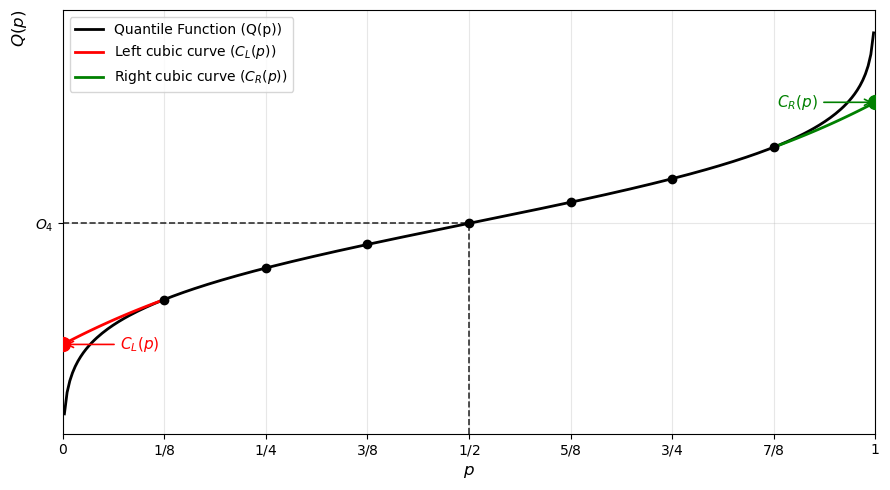

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Use Normal(0,1): Q(p) = Φ^{-1}(p), so Q(0)→-∞ and Q(1)→+∞ (curve starts below 0, goes to +∞)
def Q(p):
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return stats.norm.ppf(p)

# Octiles O_1,...,O_7 at p = 1/8, 2/8, ..., 7/8
O = [0.0]  # dummy O[0]
for i in range(1, 8):
    O.append(float(Q(i / 8.0)))
O = np.array(O)

# Cubic extrapolation endpoints (same as in Simpson / cubic+trapezoid)
# Cl(0) = cubic extrapolation at p=0;  Cr(1) = cubic extrapolation at p=1
Cl0 = 4.0 * O[1] - 6.0 * O[2] + 4.0 * O[3] - O[4]   # O_0 in the paper
Cr1 = -O[4] + 4.0 * O[5] - 6.0 * O[6] + 4.0 * O[7]  # O_8 in the paper

# Fine grid for true Q(p): curve goes from negative (p→0) to positive (p→1)
p_fine = np.linspace(0.002, 0.998, 300)
q_fine = Q(p_fine)

# Cubic segment on left: from p=0 (Cl(0)) to p=1/8 (O_1). Use cubic through (0,Cl0),(1/8,O1),(2/8,O2),(3/8,O3).
p_left = np.linspace(0, 1/8, 50)
coef_left = np.polyfit([0, 1/8, 2/8, 3/8], [Cl0, O[1], O[2], O[3]], 3)
cubic_left = np.polyval(coef_left, p_left)

# Cubic segment on right: from p=7/8 (O_7) to p=1 (Cr(1)). Cubic through (5/8,O5),(6/8,O6),(7/8,O7),(1,Cr1).
p_right = np.linspace(7/8, 1, 50)
coef_right = np.polyfit([5/8, 6/8, 7/8, 1], [O[5], O[6], O[7], Cr1], 3)
cubic_right = np.polyval(coef_right, p_right)

O4 = O[4]
y_min = min(Cl0, np.min(q_fine)) - 0.3
y_max = max(np.max(cubic_right), np.max(q_fine)) * 1.12

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
ax.set_xlim(0, 1)
ax.set_ylim(y_min, y_max)

ax.plot([0.5, 0.5], [y_min, O4], 'k--', lw=1.2, alpha=0.8)
ax.plot([0, 0.5], [O4, O4], 'k--', lw=1.2, alpha=0.8)

ax.plot(p_fine, q_fine, 'k-', lw=2, label='Quantile Function (Q(p))')
ax.plot(p_left, cubic_left, 'r-', lw=2, label='Left cubic curve ($C_L(p)$)')
ax.plot(p_right, cubic_right, 'g-', lw=2, label='Right cubic curve ($C_R(p)$)')

p_oct = np.arange(1, 8) / 8.0
ax.plot(p_oct, O[1:8], 'ko', markersize=6, zorder=5)

ax.set_xticks([0, 1/8, 1/4, 3/8, 1/2, 5/8, 3/4, 7/8, 1])
ax.set_xticklabels([r'$0$', r'$1/8$', r'$1/4$', r'$3/8$', r'$1/2$', r'$5/8$', r'$3/4$', r'$7/8$', r'$1$'])
ax.set_yticks([O4])
ax.set_yticklabels([r'$O_4$'])

ax.plot(0, Cl0, 'ro', markersize=10, zorder=6)
ax.annotate(r'$C_L(p)$', xy=(0, Cl0), xytext=(0.07, Cl0), fontsize=11, fontweight='bold', color='red',
            ha='left', va='center', arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
ax.plot(1, Cr1, 'go', markersize=10, zorder=6)
ax.annotate(r'$C_R(p)$', xy=(1, Cr1), xytext=(0.93, Cr1), fontsize=11, fontweight='bold', color='green',
            ha='right', va='center', arrowprops=dict(arrowstyle='->', color='green', lw=1.2))

ax.set_xlabel(r'$p$', fontsize=12)
ax.set_ylabel(r'$Q(p)$', fontsize=12, loc='top')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Skewed Logistics

In [14]:
# Skewed logistic example (quantile-defined): compare MLE vs quantile vs C-Trapezoid

import math
import numpy as np
import pandas as pd
from scipy.optimize import minimize, brentq
from scipy.integrate import quad


def true_s_w_skewlogistic(s, w):
    """True (s, w) from the distribution's theoretical I1, I2 (paper formulas).
    I1 = ∫_0^0.5 Q(p) dp, I2 = ∫_0.5^1 Q(p) dp; then s = (I2-I1)/log(2), w = formula.
    """
    def Q(p):
        pt = np.clip(p, 1e-12, 1 - 1e-12)
        return float(q_skewlogistic(np.array([pt]), s=s, w=w).item())
    I1, _ = quad(Q, 0, 0.5, limit=200)
    I2, _ = quad(Q, 0.5, 1, limit=200)
    lg2 = math.log(2.0)
    H = I2 - I1
    s_calc = H / lg2
    w_calc = (I2 * (1.0 + lg2) - I1 * (1.0 - lg2)) / (2.0 * H)
    return float(s_calc), float(w_calc)


def q_skewlogistic(p, s, w):
    """Quantile function Q_Z(p) = w Q_X(p) + (1-w) Q_Y(p), with
    Q_X(p)=-s log(1-p) (exponential) and Q_Y(p)=s log(p) (reflected exponential).

    Hence Q_Z(p) = s((1-w)log p - w log(1-p)).
    """
    p = np.asarray(p)
    return s * ((1.0 - w) * np.log(p) - w * np.log1p(-p))


def dqdp_skewlogistic(p, s, w):
    """Derivative dQ/dp needed for pdf via quantile: f(z)=1/Q'(p) at p=F(z)."""
    return s * ((1.0 - w) / p + w / (1.0 - p))


def sample_skewlogistic(n, s, w, rng):
    eps = np.finfo(float).eps
    u = rng.uniform(eps, 1.0 - eps, size=n)
    return q_skewlogistic(u, s=s, w=w)


def I1_I2_quartile(x):
    # Quantile (two-quartile) approximation: I1≈Q1/2, I2≈Q3/2
    Q1, Q3 = np.quantile(x, [0.25, 0.75])
    return float(Q1 / 2.0), float(Q3 / 2.0)


def I1_I2_c_trapezoid(x):
    # C-Trapezoid here = cubic+trapezoid octile formula already used in the notebook:
    # I1 = (3O1 - 2O2 + 3O3)/8, I2 = (3O5 - 2O6 + 3O7)/8 where Oi are i/8-quantiles.
    O = [0.0] + [float(np.quantile(x, i / 8.0)) for i in range(1, 8)]
    I1 = (3.0 * O[1] - 2.0 * O[2] + 3.0 * O[3]) / 8.0
    I2 = (3.0 * O[5] - 2.0 * O[6] + 3.0 * O[7]) / 8.0
    return float(I1), float(I2)


def s_w_from_I1_I2(I1, I2):
    # From the paper (skewed logistic):
    # s = (I2 - I1)/log 2
    # w = [I2(1+log 2) - I1(1-log 2)] / [2(I2 - I1)]
    lg2 = math.log(2.0)
    H = I2 - I1
    s = H / lg2
    w = (I2 * (1.0 + lg2) - I1 * (1.0 - lg2)) / (2.0 * H)
    return float(s), float(w)


def mle_skewlogistic(x, s0=None, w0=None):
    x = np.asarray(x, dtype=float)
    eps = 1e-10

    # Safe defaults
    if s0 is None or w0 is None:
        I1_q, I2_q = I1_I2_quartile(x)
        s0, w0 = s_w_from_I1_I2(I1_q, I2_q)
    s0 = float(np.clip(s0, 1e-6, np.inf))
    w0 = float(np.clip(w0, 1e-6, 1.0 - 1e-6))

    def nll(theta):
        s, w = float(theta[0]), float(theta[1])
        if not (s > 0.0 and 0.0 < w < 1.0):
            return 1e100

        # For each observation z, solve Q(p)=z for p in (0,1)
        def root_p(z):
            f = lambda p: q_skewlogistic(p, s=s, w=w) - z
            return brentq(f, eps, 1.0 - eps, maxiter=200)

        try:
            ps = np.array([root_p(z) for z in x], dtype=float)
        except Exception:
            return 1e100

        d = dqdp_skewlogistic(ps, s=s, w=w)
        if np.any(~np.isfinite(d)) or np.any(d <= 0.0):
            return 1e100

        # log f(z) = -log Q'(p)
        return float(np.sum(np.log(d)))

    res = minimize(
        nll,
        x0=np.array([s0, w0], dtype=float),
        method="L-BFGS-B",
        bounds=[(1e-8, None), (1e-8, 1.0 - 1e-8)],
    )

    s_hat, w_hat = res.x
    return float(s_hat), float(w_hat), res


def run_example(w_true, s_true=2.0, n=1000, seed=123):
    rng = np.random.default_rng(seed)
    x = sample_skewlogistic(n=n, s=s_true, w=w_true, rng=rng)

    # True (s, w) from theoretical I1, I2 (paper formulas), not the raw s_true/w_true
    s_true_calc, w_true_calc = true_s_w_skewlogistic(s_true, w_true)

    # Quantile (quartile) method
    I1_q, I2_q = I1_I2_quartile(x)
    s_q, w_q = s_w_from_I1_I2(I1_q, I2_q)

    # C-Trapezoid (cubic+trapezoid) method
    I1_c, I2_c = I1_I2_c_trapezoid(x)
    s_c, w_c = s_w_from_I1_I2(I1_c, I2_c)

    # MLE (initialized at quantile estimate)
    s_mle, w_mle, opt = mle_skewlogistic(x, s0=s_q, w0=w_q)

    return {
        "true s": s_true_calc,
        "true w": w_true_calc,
        "MLE s": s_mle,
        "MLE w": w_mle,
        "Quantile s": s_q,
        "Quantile w": w_q,
        "C-Trapezoid s": s_c,
        "C-Trapezoid w": w_c,
    }


rows = [run_example(w_true=0.5, s_true=2.0, n=1000, seed=123),
        run_example(w_true=0.25, s_true=2.0, n=1000, seed=123),
        run_example(w_true=1.0, s_true=2.0, n=1000, seed=123)]  # w=1 corresponds to exponential

df = pd.DataFrame(rows)
# Pretty formatting
for c in ["true s", "true w", "MLE s", "MLE w", "Quantile s", "Quantile w", "C-Trapezoid s", "C-Trapezoid w"]:
    df[c] = df[c].map(lambda v: float(v))

display(df)

,true s,true w,MLE s,MLE w,Quantile s,Quantile w,C-Trapezoid s,C-Trapezoid w
0,2.0,0.50,2.207973,0.520650,1.509272,0.505084,1.831839,0.518584
1,2.0,0.25,1.955902,0.254565,1.503957,0.231107,1.798032,0.255073
2,2.0,1.00,2.005222,1.000000,1.519901,1.047291,1.899453,1.017464


In [15]:
# Tukey (4-parameter) optimization to approximate an Exponential(rate=1) quantile function
import numpy as np
from scipy.optimize import minimize


def q_exp(p, rate=1.0):
    p = np.asarray(p, dtype=float)
    p = np.clip(p, 1e-8, 1 - 1e-8)
    return -np.log(1.0 - p) / rate


def q_tukey4(p, lam1, lam2, lam3, lam4):
    p = np.asarray(p, dtype=float)
    p = np.clip(p, 1e-8, 1 - 1e-8)
    return lam1 + (np.power(p, lam3) - np.power(1.0 - p, lam4)) / lam2


def objective(theta, p_grid, q_target):
    lam1, lam2, lam3, lam4 = theta
    q_hat = q_tukey4(p_grid, lam1, lam2, lam3, lam4)
    if not np.all(np.isfinite(q_hat)):
        return 1e12
    # Mean squared quantile error over p-grid
    return float(np.mean((q_hat - q_target) ** 2))


# Target exponential quantiles
rate = 1.0
p_grid = np.linspace(0.01, 0.99, 300)
q_target = q_exp(p_grid, rate=rate)

# Initial guess: location ~ 0, positive scale, moderate shape exponents
x0 = np.array([0.0, 1.0, 0.5, 0.5], dtype=float)

# Bounds for stable optimization
bounds = [
    (-10.0, 10.0),   # lam1
    (1e-6, 100.0),   # lam2 (must be positive)
    (-2.0, 5.0),     # lam3
    (-2.0, 5.0),     # lam4
]

res = minimize(
    objective,
    x0=x0,
    args=(p_grid, q_target),
    method="L-BFGS-B",
    bounds=bounds,
)

lam1, lam2, lam3, lam4 = res.x
q_fit = q_tukey4(p_grid, lam1, lam2, lam3, lam4)
rmse = float(np.sqrt(np.mean((q_fit - q_target) ** 2)))
mae = float(np.mean(np.abs(q_fit - q_target)))

print("Optimized Tukey-4 parameters for Exponential(rate=1):")
print(f"lambda1 = {lam1:.8f}")
print(f"lambda2 = {lam2:.8f}")
print(f"lambda3 = {lam3:.8f}")
print(f"lambda4 = {lam4:.8f}")
print(f"Objective (MSE) = {res.fun:.10f}")
print(f"RMSE = {rmse:.10f}")
print(f"MAE  = {mae:.10f}")
print(f"Converged: {res.success}")

Optimized Tukey-4 parameters for Exponential(rate=1):
lambda1 = 2.16067018
lambda2 = 0.48253716
lambda3 = 5.00000000
lambda4 = 0.36255577
Objective (MSE) = 0.0116506210
RMSE = 0.1079380424
MAE  = 0.0731291740
Converged: True


In [22]:
# Paper formulas for exponential / truncated-exponential example in main.tex
# Uses octiles and subarea approximations (no generic optimizer).

import numpy as np


def q_exp(p, lam):
    p = np.asarray(p, dtype=float)
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -np.log(1.0 - p) / lam


# ---------- Simulated sample from Exponential(lambda) ----------
np.random.seed(42)
true_lambda = 1.0
n = 100
u = np.random.rand(n)
x = q_exp(u, true_lambda)


# ---------- Empirical octiles O1..O7 and median O4 ----------
p_oct = np.array([i / 8 for i in range(1, 8)], dtype=float)
O = np.quantile(x, p_oct)
O1, O2, O3, O4, O5, O6, O7 = O


# ---------- Paper C-trapezoid estimator ----------
# main.tex eq:trapezoid_I1_I2
# I_L ≈ (3O1 - 2O2 + 3O3)/8, I_R ≈ (3O5 - 2O6 + 3O7)/8
# lambda = 1 / (I_L + I_R)
I_L = (3.0 * O1 - 2.0 * O2 + 3.0 * O3) / 8.0
I_R = (3.0 * O5 - 2.0 * O6 + 3.0 * O7) / 8.0
lambda_hat_c_trapezoid = 1.0 / (I_L + I_R)


# ---------- Truncated-exponential estimator ----------
# From main.tex eq:truncated_approximation and eq:truncated_mean_two:
# mu* = [(O7+O1) + 2(O6+O2) + 2(O5+O3)] / 12
# mu* = 1/lambda + 7O1/6 - O7/6  => 1/lambda = mu* - (7O1 - O7)/6
mu_star_trunc = ((O7 + O1) + 2.0 * (O6 + O2) + 2.0 * (O5 + O3)) / 12.0
inv_lambda_trunc = mu_star_trunc - (7.0 * O1 - O7) / 6.0
lambda_hat_trunc = 1.0 / inv_lambda_trunc


# ---------- Paper quartile-fitting baseline for exponential ----------
# main.tex: lambda = log(2)/O4
lambda_hat_quartile = np.log(2.0) / O4

# MLE baseline for reference
lambda_hat_mle = 1.0 / np.mean(x)


# ---------- Report ----------
def pct_err(est, true_val):
    return 100.0 * (est / true_val - 1.0)


print("Exponential parameter estimation using paper formulas")
print(f"True lambda = {true_lambda:.6f}, n = {n}")
print()
print("From C-trapezoid octile formula:")
print(f"lambda_hat_c_trapezoid = {lambda_hat_c_trapezoid:.6f}  | error = {pct_err(lambda_hat_c_trapezoid, true_lambda):+.2f}%")
print()
print("From truncated-exponential section (octile/subarea formula):")
print(f"lambda_hat_trunc = {lambda_hat_trunc:.6f}  | error = {pct_err(lambda_hat_trunc, true_lambda):+.2f}%")
print()
print("From quartile fitting (median formula):")
print(f"lambda_hat_quartile = {lambda_hat_quartile:.6f}  | error = {pct_err(lambda_hat_quartile, true_lambda):+.2f}%")
print()
print("MLE baseline:")
print(f"lambda_hat_mle = {lambda_hat_mle:.6f}  | error = {pct_err(lambda_hat_mle, true_lambda):+.2f}%")
print()
print("Empirical octiles used:")
for i, oi in enumerate(O, start=1):
    print(f"O{i} = {oi:.6f}")

Exponential parameter estimation using paper formulas
True lambda = 1.000000, n = 100

From C-trapezoid octile formula:
lambda_hat_c_trapezoid = 1.163474  | error = +16.35%

From truncated-exponential section (octile/subarea formula):
lambda_hat_trunc = 1.203173  | error = +20.32%

From quartile fitting (median formula):
lambda_hat_quartile = 1.110812  | error = +11.08%

MLE baseline:
lambda_hat_mle = 1.093197  | error = +9.32%

Empirical octiles used:
O1 = 0.107049
O2 = 0.214698
O3 = 0.376018
O4 = 0.624000
O5 = 0.912707
O6 = 1.310093
O7 = 1.912742
